In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import xarray as xr
import numpy as np
from distributed import Client, LocalCluster
import dask
import pickle
import os
from scipy.stats import linregress
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import linregress
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern, RationalQuadratic
import joblib # For saving our models
import time
import emcee
from matplotlib.ticker import FuncFormatter
import numpy as np
import pickle
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from scipy import stats
from scipy.signal import find_peaks
import matplotlib.gridspec as gridspec
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
plt.rcParams['text.usetex'] = True
import corner # The library for creating corner plots

# Loadings neaded for LaTex

In [2]:
# Get the current PATH
original_path = os.environ.get('PATH', '')
latex_path = '/glade/u/apps/casper/24.12/spack/opt/spack/texlive/20240312/gcc/12.4.0/nm7e/bin/x86_64-linux' 
# Prepend the LaTeX path to the system's PATH
# We prepend it to make sure it's found first.
os.environ['PATH'] = latex_path + os.pathsep + original_path
plt.rcParams['text.usetex'] = True

# Load regime & control dataframes

In [3]:
read_path='/glade/u/home/mckenna/work/regime_dataframes/'
df_regime2 = pd.read_pickle(read_path+'df_regime2_perturbed_members.pkl')
df_cntl_regime2 = pd.read_pickle(read_path+'df_regime2_cntl.pkl')
df_cntl = pd.read_pickle(read_path+'df_all_regimes_cntl.pkl')
print(df_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
#print(df_cntl_regime2[['RESTOM_PD', 'LWP_PD', 'WROF_PD','PAF_PD']].T)
#print(df_cntl[['RESTOM_PD', 'LWP_PD_regime2', 'WROF_PD_regime2','PAF_PD_regime2']].T)

                  0          1          2           3          4          5   \
RESTOM_PD  22.767999  10.145342  17.262480   -6.977647  21.915214  21.711642   
LWP_PD      3.057743  37.931980  10.159395  147.974965   5.190044   4.751587   
WROF_PD     0.799337   0.885769   0.920615    0.054271   0.803136   0.778199   
PAF_PD      0.005089   0.004556   0.004543    0.063875   0.002875   0.003208   

                   6          7          8           9   ...         40  \
RESTOM_PD   -7.650290  19.457138  14.639741   -2.185409  ...  -1.116216   
LWP_PD     148.395507  13.462151  14.315497  110.949258  ...  86.064168   
WROF_PD      0.053720   0.941904   0.942558    0.342422  ...   0.520146   
PAF_PD       0.062392   0.010737   0.009245    0.015458  ...   0.008924   

                   41         42          43         44         45         46  \
RESTOM_PD   -7.637161  23.359594   -7.432411  16.070160  16.228917  19.658779   
LWP_PD     148.083371   4.195462  148.166729  15.888349  10.1

# Plot KDEs of posteriors for Radiation Only, Radation + LWP, and Radiation + LWP + Process Rates

In [4]:
def analyze_modes_kde(data, split_point=None):
    if len(data) < 10: return None
    try:
        kde = stats.gaussian_kde(data)
        x_axis = np.linspace(data.min(), data.max(), 1000)
        pdf = kde(x_axis)
        if split_point is None:
            peak_indices, _ = find_peaks(pdf, height=0.01 * np.max(pdf), prominence=0.01)
            if len(peak_indices) > 2:
                sorted_peak_indices = sorted(peak_indices, key=lambda i: pdf[i], reverse=True)
                peak_indices = np.sort(sorted_peak_indices[:2])
            if len(peak_indices) != 2: return None
            valley_index = peak_indices[0] + np.argmin(pdf[peak_indices[0]:peak_indices[1]])
            split_point = x_axis[valley_index]
        
        mode1_data = data[data < split_point]
        mode2_data = data[data >= split_point]
        if len(mode1_data) == 0 or len(mode2_data) == 0: return None

        return {
            'means': [mode1_data.mean(), mode2_data.mean()],
            'stds': [mode1_data.std(), mode2_data.std()],
            'weights': [len(mode1_data) / len(data), len(mode2_data) / len(data)],
            'plot_info': {'split_point': split_point}
        }
    except Exception as e: return None


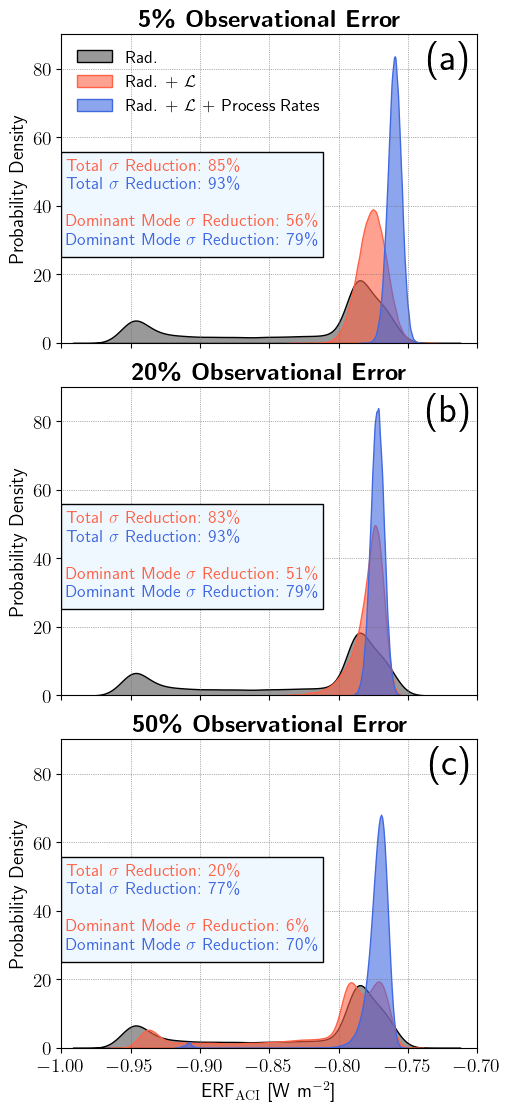

done


In [104]:
# --- Main Configuration ---
PLOT_PROXIES = False # <<< SET YOUR BOOLEAN HERE
PLOT_SPLIT_POINT = False
post_GPerr_prop_bool = False

# --- 1. Centralized Data Loading ---
if post_GPerr_prop_bool:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_prox': 'Radiation_Plus_LWP_ProxyRates_{}PercErr_VarCov_nothin_withPostGPerrProp'
    }
else:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_prox': 'Radiation_Plus_LWP_ProxyRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp'
        #'rad_lwp_prox': 'Radiation_Plus_LWP_PRECL_WROF_{}PercErr_VarCov_nothin_withoutPostGPerrProp'
    }

error_percs = [5, 20, 50]
all_data = {}

for name, template in experiment_bases.items():
    all_data[name] = {}
    if '{}' in template: # It's an experiment with varying error
        for perc in error_percs:
            exp_name = template.format(perc)
            with open(f'./mcmc_prop/constrained_prop_{exp_name}.pkl', "rb") as f:
                all_data[name][perc] = pickle.load(f)
    else: # It's the baseline experiment
        with open(f'./mcmc_prop/constrained_prop_{template}.pkl', "rb") as f:
            all_data[name] = pickle.load(f)

# --- 2. Setup Figure and Analysis ---
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 11), constrained_layout=True)
Fontsize = 14

plot_configs = [
    {'label': 'Rad.', 'color': 'k', 'alpha': 0.4, 'data': all_data['rad']},
    {'label': r'Rad. + $\mathcal{L}$', 'color': 'tomato', 'alpha': 0.6, 'data_key': 'rad_lwp'},
    {'label': r'Rad. + $\mathcal{L}$ + Process Rates', 'color': 'royalblue', 'alpha': 0.6, 'data_key': 'rad_lwp_proc'},
]
if PLOT_PROXIES:
    plot_configs.append({'label': r'Rad. + $\mathcal{L}$ + Proxy Rates', 'color': 'darkgoldenrod', 'alpha': 0.6, 'data_key': 'rad_lwp_prox'})

# Use the 'rad' case to define the split point for all subplots
rad_erf_data = all_data['rad']['posteriors']['ERF_ACI']
rad_mode_dict = analyze_modes_kde(rad_erf_data)
rad_split_point = rad_mode_dict['plot_info']['split_point']
rad_mode1_std = rad_mode_dict['stds'][0]
rad_mode2_std = rad_mode_dict['stds'][1]
rad_std = np.std(rad_erf_data)

# --- 3. Main Loop for Plotting and Analysis ---
for i, (ax, perc) in enumerate(zip(axs, error_percs)):
    stats_for_plot = []
    # Plot the baseline radiation case on every subplot
    sns.kdeplot(data=rad_erf_data, ax=ax, color='k', fill=True, alpha=0.4, label='Rad.')

    # Loop through the other experiment types
    for config in plot_configs[1:]: # Skip the baseline 'rad'
        data_key = config['data_key']
        erf_data = all_data[data_key][perc]['posteriors']['ERF_ACI']
        
        sns.kdeplot(data=erf_data, ax=ax, color=config['color'], fill=True, alpha=config['alpha'], label=config['label'])
        
        # Analyze modes and calculate stats
        mode_dict = analyze_modes_kde(erf_data, split_point=rad_split_point)
        total_std = np.std(erf_data)
        
        mode1_std, mode2_std = (total_std, total_std) if mode_dict is None else (mode_dict['stds'][0], mode_dict['stds'][1])
        
        stats_for_plot.append({
            'color': config['color'],
            'total_reduction': (total_std - rad_std) / rad_std * 100,
            'dominant_reduction': (mode2_std - rad_mode2_std) / rad_mode2_std * 100,
        })
        if PLOT_SPLIT_POINT and mode_dict:
            ax.axvline(mode_dict['plot_info']['split_point'], lw=1, ls='dashed', c=config['color'])

    # --- Annotation ---
    start_y, delta_y, gap = (0.6, 0.06, 0.025)
    text_items = []
    for stat in stats_for_plot:
        text_items.append((f"Total $\\sigma$ Reduction: {abs(stat['total_reduction']):.0f}\%", stat['color']))
    text_items.append(("", "white")) # Add a gap
    for stat in stats_for_plot:
        text_items.append((f"Dominant Mode $\\sigma$ Reduction: {abs(stat['dominant_reduction']):.0f}\%", stat['color']))
    
    y_pos = start_y
    for j, (text, color) in enumerate(text_items):
        if "gap" in text: y_pos -= gap
        else:
             ax.text(0.01, y_pos, text, ha='left', va='top', color=color, transform=ax.transAxes, fontsize=Fontsize*0.9, zorder=10)
             y_pos -= delta_y

    # --- General Formatting ---
    ax.set_title(f'\\textbf{{{perc}\% Observational Error}}', fontsize=Fontsize*1.25)
    ax.text(0.99, 0.98, f'({chr(97+i)})', fontsize=Fontsize*2., transform=ax.transAxes, va='top', ha='right')
    ax.set_ylim(0, 90)
    ax.set_xlim(-1.0, -0.7)
    ax.set_ylabel('Probability Density', fontsize=Fontsize)
    ax.grid(which='both', lw=0.5, c='dimgray', ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    #ax.axvline(df_cntl_regime2['ERF_ACI'].values[0],lw=2,ls='dashed',color='k',label='CNTL (Truth)')
    if i < len(axs) - 1: ax.set_xticklabels([])
    
    box_height = 0.44 if PLOT_PROXIES else 0.34
    box_y = 0.18 if PLOT_PROXIES else 0.28
    rect = Rectangle((0.0, box_y), 0.63, box_height, facecolor='aliceblue', alpha=0.99, edgecolor='k', transform=ax.transAxes, zorder=9)
    ax.add_patch(rect)

axs[0].legend(loc='upper left', framealpha=False, fontsize=Fontsize*0.9)
axs[-1].set_xlabel(r'ERF$_\mathrm{ACI}$ [W m$^{-2}$]', fontsize=Fontsize)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
#file_name = f'fig_ERFaci_posterior_PDFs.png'
file_name = f'fig_ERFaci_posterior_PDFs_with_proxies.png'
#plt.savefig(save_path + file_name, dpi=300)
plt.show()
plt.close()
print('done')

In [95]:
# --- Main Configuration ---
PLOT_PROXIES = True # <<< SET YOUR BOOLEAN HERE
PLOT_SPLIT_POINT = False
post_GPerr_prop_bool = False


experiment_bases = {
    'rad': 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp_wrof': 'Radiation_Plus_LWP_WROF_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp_paf': 'Radiation_Plus_LWP_PAF_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp_precl': 'Radiation_Plus_LWP_PRECL_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
    'rad_lwp_prox': 'Radiation_Plus_LWP_ProxyRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
}


error_percs = [5, 20, 50]
#error_percs = [5]
all_data = {}

for name, template in experiment_bases.items():
    all_data[name] = {}
    if '{}' in template: # It's an experiment with varying error
        for perc in error_percs:
            exp_name = template.format(perc)
            with open(f'./mcmc_prop/constrained_prop_{exp_name}.pkl', "rb") as f:
                all_data[name][perc] = pickle.load(f)
    else: # It's the baseline experiment
        with open(f'./mcmc_prop/constrained_prop_{template}.pkl', "rb") as f:
            all_data[name] = pickle.load(f)

# --- 2. Setup Figure and Analysis ---
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(5, 11), constrained_layout=True)
Fontsize = 14

plot_configs = [
    {'label': 'Rad.', 'color': 'k', 'alpha': 0.35, 'data': all_data['rad'],'fill':True,'ls':'solid','lw':0},
    {'label': r'Rad. + $\mathcal{L}$', 'color': 'tomato', 'alpha': 0.35, 'data_key': 'rad_lwp','fill':True,'ls':'solid','lw':0},
    {'label': r'Rad. + $\mathcal{L}$ + Process Rates', 'color': 'royalblue', 'alpha': 0.35, 'data_key': 'rad_lwp_proc','fill':True,'ls':'solid','lw':0},
    
    {'label': r'Rad. + $\mathcal{L}$ + WROF', 'color': 'k', 'alpha': 1.0, 'data_key': 'rad_lwp_wrof','fill':False,'ls':'dashed','lw':1.5},
    {'label': r'Rad. + $\mathcal{L}$ + PAF', 'color': 'k', 'alpha': 1.0, 'data_key': 'rad_lwp_paf','fill':False,'ls':'dotted','lw':1.5},
    {'label': r'Rad. + $\mathcal{L}$ + $\mathcal{P}$', 'color': 'k', 'alpha': 1.0, 'data_key': 'rad_lwp_precl','fill':False,'ls':'dashdot','lw':1.5},
    {'label': r'Rad. + $\mathcal{L}$ + All Proxy Rates', 'color': 'k', 'alpha': 1.0, 'data_key': 'rad_lwp_prox','fill':False,'ls':'solid','lw':2.5},
]


# Use the 'rad' case to define the split point for all subplots
rad_erf_data = all_data['rad']['posteriors']['ERF_ACI']

# --- 3. Main Loop for Plotting and Analysis ---
for i, (ax, perc) in enumerate(zip(axs, error_percs)):
    print(i)
    stats_for_plot = []
    # Plot the baseline radiation case on every subplot
    sns.kdeplot(data=rad_erf_data, ax=ax, color='k', fill=True, alpha=0.2, label='Rad.',lw=0)

    # Loop through the other experiment types
    for config in plot_configs[1:]: # Skip the baseline 'rad'
        data_key = config['data_key']
        print(data_key)
        erf_data = all_data[data_key][perc]['posteriors']['ERF_ACI']
        
        sns.kdeplot(data=erf_data, ax=ax, color=config['color'], fill=config['fill'], alpha=config['alpha'], label=config['label'],lw=config['lw'],ls=config['ls'])
        
    # --- General Formatting ---
    ax.set_title(f'\\textbf{{{perc}\% Observational Error}}', fontsize=Fontsize*1.25)
    ax.text(0.99, 0.98, f'({chr(97+i)})', fontsize=Fontsize*2., transform=ax.transAxes, va='top', ha='right')
    ax.set_ylim(0, 90)
    ax.set_xlim(-1.0, -0.7)
    ax.set_ylabel('Probability Density', fontsize=Fontsize)
    ax.grid(which='both', lw=0.5, c='dimgray', ls='dotted')
    ax.tick_params(labelsize=Fontsize)
    if i < len(axs) - 1: ax.set_xticklabels([])
    

axs[0].legend(loc='upper left', framealpha=True, fontsize=Fontsize*0.9,labelspacing=0.2,edgecolor='k')
axs[-1].set_xlabel(r'ERF$_\mathrm{ACI}$ [W m$^{-2}$]', fontsize=Fontsize)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
#file_name = f'fig_ERFaci_posterior_PDFs.png'
file_name = f'fig_ERFaci_posterior_PDFs_with_proxies.png'
plt.savefig(save_path + file_name, dpi=300)
#plt.show()
plt.close()
print('done')

0
rad_lwp
rad_lwp_proc
rad_lwp_wrof
rad_lwp_paf
rad_lwp_precl
rad_lwp_prox
1
rad_lwp
rad_lwp_proc
rad_lwp_wrof
rad_lwp_paf
rad_lwp_precl
rad_lwp_prox
2
rad_lwp
rad_lwp_proc
rad_lwp_wrof
rad_lwp_paf
rad_lwp_precl
rad_lwp_prox
done


# Plot joint KDEs of x_auto and x_accr

--- Loading and preparing dataframes from .pkl files ---
Loaded and created DataFrame for rad
Loaded and created DataFrame for rad_lwp @ 5%
Loaded and created DataFrame for rad_lwp @ 20%
Loaded and created DataFrame for rad_lwp @ 50%
Loaded and created DataFrame for rad_lwp_proc @ 5%
Loaded and created DataFrame for rad_lwp_proc @ 20%
Loaded and created DataFrame for rad_lwp_proc @ 50%


/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/wor

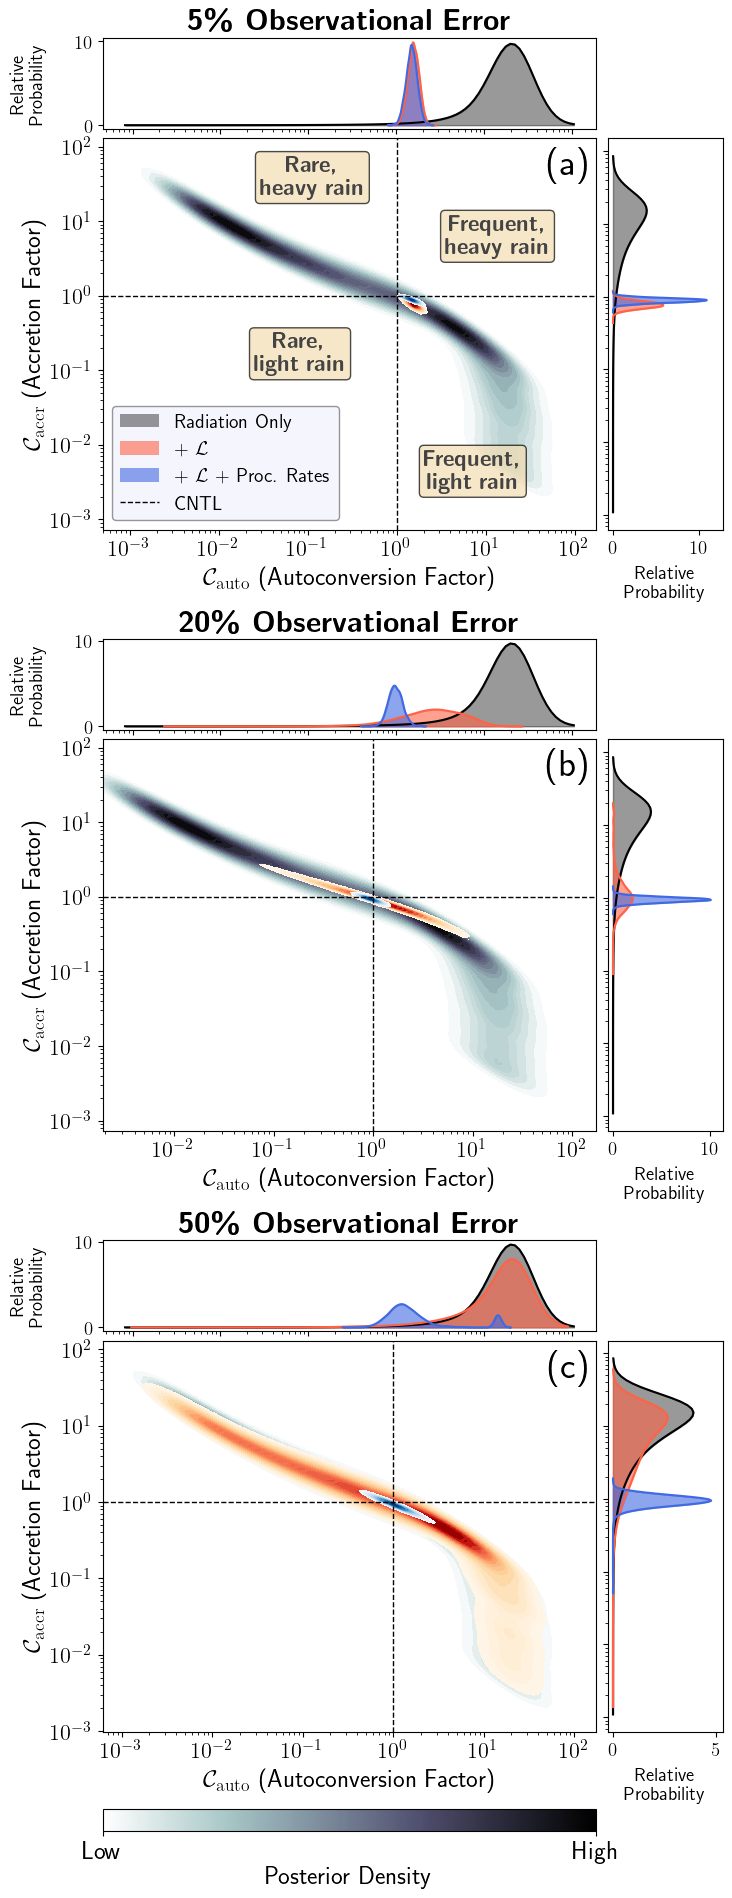

done


In [44]:
# ==============================================================================
# 0. DATA LOADING AND PREPARATION
# ==============================================================================
# This new section replaces the need to have pre-loaded dataframes.
post_GPerr_prop_bool = False
# Define the experiments and error levels we need
if post_GPerr_prop_bool:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withPostGPerrProp'
    }

else:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp'
    }

error_percs = [5, 20, 50]
all_dataframes = {}
MAX_SAMPLES_FOR_PLOT = 5000
sub_samp_bool = True

print("--- Loading and preparing dataframes from .pkl files ---")
for name, template in experiment_bases.items():
    all_dataframes[name] = {}
    if '{}' in template: # It's an experiment with varying error
        for perc in error_percs:
            exp_name = template.format(perc)
            filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
            with open(filepath, "rb") as f:
                data_dict = pickle.load(f)
            
            # Create a DataFrame from the posterior input chains
            df = pd.DataFrame({
                'x_auto': data_dict['posteriors']['inputs']['x_auto'],
                'x_accr': data_dict['posteriors']['inputs']['x_accr']
            })
            if sub_samp_bool:
                df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42) # Subsample the data
            
            all_dataframes[name][perc] = df
            print(f"Loaded and created DataFrame for {name} @ {perc}%")
            
    else: # It's the baseline 'rad' experiment
        filepath = f'./mcmc_prop/constrained_prop_{template}.pkl'
        with open(filepath, "rb") as f:
            data_dict = pickle.load(f)
        
        df = pd.DataFrame({
            'x_auto': data_dict['posteriors']['inputs']['x_auto'],
            'x_accr': data_dict['posteriors']['inputs']['x_accr']
        })
        if sub_samp_bool:
            df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42) # Subsample the data
        
        all_dataframes[name] = df
        print(f"Loaded and created DataFrame for {name}")

# Assume df_cntl is loaded from elsewhere for the CNTL lines, or define it here
# For this example, let's create a dummy one since it's just for the (1,1) point
df_cntl = pd.DataFrame({'x_auto': [1.0], 'x_accr': [1.0]})


# ==============================================================================
# 1. HELPER FUNCTION TO DRAW ONE PANEL (Unchanged)
# ==============================================================================
def plot_panel(ax_joint, ax_marg_x, ax_marg_y, df_rad, df_lwp, df_lwp_proc, plot_params):
    """Draws a complete joint+marginal KDE plot with CORRECTED marginals for log scale."""
    color1, color2, color3 = plot_params['colors']
    cmap1, cmap2, cmap3 = plot_params['cmaps']
    alpha1_2d, alpha2_2d, alpha3_2d = plot_params['alphas_2d']
    alpha1_1d, alpha2_1d, alpha3_1d = plot_params['alphas_1d']
    fill, linewidths = plot_params['fill'], plot_params['linewidths']
    gridsize, levels = plot_params['gridsize'], plot_params['levels']
    Fontsize = plot_params['Fontsize']

    sns.kdeplot(data=df_rad, x='x_auto', y='x_accr', cmap=cmap1, fill=fill, alpha=alpha1_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)
    sns.kdeplot(data=df_lwp, x='x_auto', y='x_accr', cmap=cmap2, fill=fill, alpha=alpha2_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)
    sns.kdeplot(data=df_lwp_proc, x='x_auto', y='x_accr', cmap=cmap3, fill=fill, alpha=alpha3_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)

    def plot_corrected_kde(data, var, ax, orientation, color, alpha, **kwargs):
        kde_calc = sns.kdeplot(data=data, x=var if orientation == 'horizontal' else None, y=var if orientation == 'vertical' else None, ax=ax, log_scale=True, linewidth=0, **kwargs)
        line = ax.get_lines()[-1]
        x, y = line.get_data()
        line.remove()
        if orientation == 'horizontal':
            y_transformed = y * x
            ax.plot(x, y_transformed, color=color)
            ax.fill_between(x, 0, y_transformed, color=color, alpha=alpha)
        else:
            x_transformed = y * x
            ax.plot(x_transformed, y, color=color)
            ax.fill_betweenx(y, 0, x_transformed, color=color, alpha=alpha)

    plot_corrected_kde(df_rad, 'x_auto', ax_marg_x, 'horizontal', color1, alpha1_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp, 'x_auto', ax_marg_x, 'horizontal', color2, alpha2_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_proc, 'x_auto', ax_marg_x, 'horizontal', color3, alpha3_1d, gridsize=gridsize)
    plot_corrected_kde(df_rad, 'x_accr', ax_marg_y, 'vertical', color1, alpha1_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp, 'x_accr', ax_marg_y, 'vertical', color2, alpha2_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_proc, 'x_accr', ax_marg_y, 'vertical', color3, alpha3_1d, gridsize=gridsize)

# ==============================================================================
# 2. DEFINE PLOTTING PARAMETERS (Unchanged)
# ==============================================================================
Fontsize=18
plot_params = { 'gridsize': 100, 'levels': np.arange(0.05, 1.05, 0.05), 'colors': ('k', 'tomato', 'royalblue'), 'cmaps': ('bone_r', 'OrRd', 'Blues'), 'alphas_2d': (1., 1., 1.), 'alphas_1d': (0.4, 0.6, 0.6), 'fill': True, 'linewidths': 0, 'Fontsize': Fontsize }
cntl_x_auto = df_cntl['x_auto'].iloc[0]
cntl_x_accr = df_cntl['x_accr'].iloc[0]

# ==============================================================================
# 3. CREATE THE FIGURE LAYOUT AND AXES LISTS (More structured)
# ==============================================================================
fig = plt.figure(figsize=(8, 22))
gs = gridspec.GridSpec(17, 5, hspace=0.1, wspace=0.1)
panel_axes = [
    (fig.add_subplot(gs[1:5, 0:4]), fig.add_subplot(gs[0, 0:4]), fig.add_subplot(gs[1:5, 4])),
    (fig.add_subplot(gs[7:11, 0:4]), fig.add_subplot(gs[6, 0:4]), fig.add_subplot(gs[7:11, 4])),
    (fig.add_subplot(gs[13:17, 0:4]), fig.add_subplot(gs[12, 0:4]), fig.add_subplot(gs[13:17, 4]))
]
joint_axes = [axes[0] for axes in panel_axes]
marg_x_axes = [axes[1] for axes in panel_axes]
marg_y_axes = [axes[2] for axes in panel_axes]

# ==============================================================================
# 4. MAIN PLOTTING LOOP (Replaces repetitive calls)
# ==============================================================================
df_rad_base = all_dataframes['rad']
for i, perc in enumerate(error_percs):
    # Get the correct axes for this panel
    ax_joint, ax_marg_x, ax_marg_y = panel_axes[i]
    
    # Get the correct dataframes for this error percentage
    df_lwp_panel = all_dataframes['rad_lwp'][perc]
    df_lwp_proc_panel = all_dataframes['rad_lwp_proc'][perc]
    
    # Call the panel plotting function
    plot_panel(ax_joint, ax_marg_x, ax_marg_y, df_rad_base, df_lwp_panel, df_lwp_proc_panel, plot_params)
    
# ==============================================================================
# 5. FINAL PLOT TOUCHES (Largely unchanged, but using axes lists)
# ==============================================================================
fac = 0.75
panel_titles = [r"\textbf{5\% Observational Error}", r"\textbf{20\% Observational Error}", r"\textbf{50\% Observational Error}"]
for i, ax in enumerate(marg_x_axes):
    ax.set_title(panel_titles[i], fontsize=Fontsize*1.2)
    ax.set_ylabel('Relative\nProbability', fontsize=Fontsize * fac)
    plt.setp(ax.get_xticklabels(), visible=False) # Simplified removal
    ax.tick_params(axis='y', which='major', labelsize=Fontsize * fac)

for ax in joint_axes:
    ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
    ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
    ax.tick_params(axis='both', which='major', labelsize=Fontsize - 2)
    ax.axhline(cntl_x_accr, ls='dashed', lw=1, zorder=10, c='k')
    ax.axvline(cntl_x_auto, ls='dashed', lw=1, zorder=10, c='k')

for ax in marg_y_axes:
    ax.set_xlabel('Relative\nProbability', fontsize=Fontsize * fac)
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='x', which='major', labelsize=Fontsize * fac)

# Create legend on the first panel
legend_elements = [
    mpatches.Patch(facecolor=plot_params['colors'][0], alpha=plot_params['alphas_1d'][0], label='Radiation Only'),
    mpatches.Patch(facecolor=plot_params['colors'][1], alpha=plot_params['alphas_1d'][1], label=r'+ $\mathcal{L}$'),
    mpatches.Patch(facecolor=plot_params['colors'][2], alpha=plot_params['alphas_1d'][2], label=r'+ $\mathcal{L}$ + Proc. Rates'),
    plt.Line2D([0], [0], color='k', label='CNTL', lw=1,ls='dashed')
]



# ==============================================================================
# 6. QUADRANT ANNOTATION ON PANEL (a)
# ==============================================================================
ax_annotate = joint_axes[0]
quadrant_style = dict(
    fontsize=Fontsize * 0.9,
    color='#444444',
    ha='center',
    va='center',
    fontstyle='italic',
    fontweight='bold',
    transform=ax_annotate.transAxes,
    zorder=20,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.7, edgecolor='k')
)

# Upper-left quadrant: low C_auto, high C_accr
#ax_annotate.text(0.4, 0.85, 'Rare,\nheavy rain', **quadrant_style)
ax_annotate.text(0.425, 0.9, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)

# Upper-right quadrant: high C_auto, high C_accr
ax_annotate.text(0.8, 0.75, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)

# Lower-left quadrant: low C_auto, low C_accr
ax_annotate.text(0.4, 0.45, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)

# Lower-right quadrant: high C_auto, low C_accr
ax_annotate.text(0.75, 0.15, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)


# ==============================================================================
# 7. HORIZONTAL COLORBAR AT BOTTOM
# ==============================================================================
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get position of bottom joint axis for placement reference
pos = joint_axes[2].get_position()

# Add colorbar axis below the bottom panel
cax = fig.add_axes([pos.x0, pos.y0 - 0.045, pos.width * 1., 0.01])

norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap='bone_r'),
    cax=cax,
    orientation='horizontal'
)
cb.set_ticks([0, 1])
cb.set_ticklabels(['Low', 'High'], fontsize=Fontsize * 1.)
cb.set_label('Posterior Density', fontsize=Fontsize * 1., labelpad=2)


joint_axes[0].legend(handles=legend_elements, loc='lower left', fontsize=Fontsize - 4, framealpha=0.4, edgecolor='k',facecolor='lavender')

# Add Panel Labels (a, b, c)
for i, ax in enumerate(joint_axes):
    ax.text(0.99,0.98, f'({chr(97+i)})', fontsize=Fontsize*1.5, va='top', ha='right', transform=ax.transAxes)

fig.align_labels()

for ax in marg_x_axes:
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), visible=False)

for ax in marg_y_axes:
    ax.set_ylabel('')
    plt.setp(ax.get_yticklabels(), visible=False)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'fig_xauto_accr_joint_KDE_3panel.png'
#plt.savefig(save_path + file_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('done')

In [86]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter, MaxNLocator
from matplotlib.ticker import FixedLocator

# ==============================================================================
# 0. DATA LOADING AND PREPARATION (Unchanged)
# ==============================================================================
post_GPerr_prop_bool = False
if post_GPerr_prop_bool:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withPostGPerrProp'
    }
else:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp'
    }
error_percs = [5, 20, 50]
all_dataframes = {}
MAX_SAMPLES_FOR_PLOT = 10000 # Using 10k for better resolution
sub_samp_bool = False
print("--- Loading and preparing dataframes from .pkl files ---")
for name, template in experiment_bases.items():
    all_dataframes[name] = {}
    if '{}' in template:
        for perc in error_percs:
            exp_name = template.format(perc)
            filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
            with open(filepath, "rb") as f: data_dict = pickle.load(f)
            df = pd.DataFrame({'x_auto': data_dict['posteriors']['inputs']['x_auto'], 'x_accr': data_dict['posteriors']['inputs']['x_accr']})
            if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
                df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
            all_dataframes[name][perc] = df
    else:
        filepath = f'./mcmc_prop/constrained_prop_{template}.pkl'
        with open(filepath, "rb") as f: data_dict = pickle.load(f)
        df = pd.DataFrame({'x_auto': data_dict['posteriors']['inputs']['x_auto'], 'x_accr': data_dict['posteriors']['inputs']['x_accr']})
        if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
            df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
        all_dataframes[name] = df
df_cntl = pd.DataFrame({'x_auto': [1.0], 'x_accr': [1.0]})

# ==============================================================================
# 1. CORRECTED HELPER FUNCTION (Unchanged from your last version)
# ==============================================================================
def plot_panel_corrected(ax_joint, ax_marg_x, ax_marg_y, df_rad, df_lwp, df_lwp_proc, plot_params):
    color1, color2, color3 = plot_params['colors']
    cmap1, cmap2, cmap3 = plot_params['cmaps']
    alpha1_1d, alpha2_1d, alpha3_1d = plot_params['alphas_1d']
    gridsize, levels = plot_params['gridsize'], plot_params['levels']
    dfs = [df_rad, df_lwp, df_lwp_proc]
    for k, df in enumerate(dfs):
        df['log10_x_auto'] = np.log10(df['x_auto'])
        df['log10_x_accr'] = np.log10(df['x_accr'])
        sns.kdeplot(data=df, x='log10_x_auto', y='log10_x_accr', cmap=plot_params['cmaps'][k], fill=True, alpha=1.0, ax=ax_joint, gridsize=gridsize, levels=levels, linewidths=0)
        sns.kdeplot(data=df, x='log10_x_auto', ax=ax_marg_x, color=plot_params['colors'][k], fill=True, alpha=plot_params['alphas_1d'][k])
        sns.kdeplot(data=df, y='log10_x_accr', ax=ax_marg_y, color=plot_params['colors'][k], fill=True, alpha=plot_params['alphas_1d'][k])
        df.drop(columns=['log10_x_auto', 'log10_x_accr'], inplace=True)

# ==============================================================================
# 2. DEFINE PLOTTING PARAMETERS (Unchanged)
# ==============================================================================
Fontsize=18
plot_params = { 'gridsize': 100, 'levels': np.arange(0.05, 1.05, 0.05), 'colors': ('k', 'tomato', 'royalblue'), 
               'cmaps': ('bone_r', 'OrRd', 'Blues'), 'alphas_2d': (1., 1., 1.), 
               'alphas_1d': (0.4, 0.6, 0.6), 'fill': True, 'linewidths': 0, 'Fontsize': Fontsize }
cntl_x_auto = df_cntl['x_auto'].iloc[0]
cntl_x_accr = df_cntl['x_accr'].iloc[0]

# ==============================================================================
# 3. CREATE THE FIGURE LAYOUT AND AXES LISTS (Unchanged)
# ==============================================================================
fig = plt.figure(figsize=(8, 22))
gs = gridspec.GridSpec(17, 5, hspace=0.1, wspace=0.1)
panel_axes = [
    (fig.add_subplot(gs[1:5, 0:4]), fig.add_subplot(gs[0, 0:4]), fig.add_subplot(gs[1:5, 4])),
    (fig.add_subplot(gs[7:11, 0:4]), fig.add_subplot(gs[6, 0:4]), fig.add_subplot(gs[7:11, 4])),
    (fig.add_subplot(gs[13:17, 0:4]), fig.add_subplot(gs[12, 0:4]), fig.add_subplot(gs[13:17, 4]))
]
joint_axes = [axes[0] for axes in panel_axes]
marg_x_axes = [axes[1] for axes in panel_axes]
marg_y_axes = [axes[2] for axes in panel_axes]

# ==============================================================================
# 4. MAIN PLOTTING LOOP (Unchanged)
# ==============================================================================
df_rad_base = all_dataframes['rad']
for i, perc in enumerate(error_percs):
    ax_joint, ax_marg_x, ax_marg_y = panel_axes[i]
    df_lwp_panel = all_dataframes['rad_lwp'][perc]
    df_lwp_proc_panel = all_dataframes['rad_lwp_proc'][perc]
    plot_panel_corrected(ax_joint, ax_marg_x, ax_marg_y, df_rad_base, df_lwp_panel, df_lwp_proc_panel, plot_params)
    
# ==============================================================================
# 5. FINAL PLOT TOUCHES (THIS IS THE CORRECTED PART)
# ==============================================================================
# --- Function to format tick labels from log10 values to "10^x" format ---
def log_tick_formatter(val, pos=None):
    return f"$10^{{{int(val)}}}$"

fac = 0.75
panel_titles = [r"\textbf{5\% Observational Error}", r"\textbf{20\% Observational Error}", r"\textbf{50\% Observational Error}"]


log_ticks = [-2, -1, 0, 1]
log_labels = [f"$10^{{{int(t)}}}$" for t in log_ticks]

# 2. Generate the positions for all minor ticks in log10 space
minor_tick_positions = []
# Loop through the integer powers of 10
for i in range(-3,2):
    # Add the positions for 2*10^i, 3*10^i, ..., 9*10^i
    minor_tick_positions.extend([i + np.log10(j) for j in range(2, 10)])

# 3. Create a locator object with these fixed positions
minor_locator = FixedLocator(minor_tick_positions)
# --- END: NEW CODE FOR MINOR TICKS ---

fac = 0.75
panel_titles = [r"\textbf{5\% Observational Error}", r"\textbf{20\% Observational Error}", r"\textbf{50\% Observational Error}"]

for i, (ax_joint, ax_marg_x, ax_marg_y) in enumerate(panel_axes):
    # --- 2. Set the ticks and labels manually ---
    ax_joint.set_xticks(log_ticks)
    ax_joint.set_xticklabels(log_labels)
    ax_joint.set_yticks(log_ticks)
    ax_joint.set_yticklabels(log_labels)
    
    ax_marg_x.set_xticks(log_ticks)
    ax_marg_y.set_yticks(log_ticks)

    # --- 3. Set the axis limits with padding ---
    padding = 0.5
    #ax_joint.set_xlim(log_ticks[0] - padding, log_ticks[-1] + padding)
    #ax_joint.set_ylim(log_ticks[0] - padding, log_ticks[-1] + padding)
    #ax_marg_x.set_xlim(log_ticks[0] - padding, log_ticks[-1] + padding)
    #ax_marg_y.set_ylim(log_ticks[0] - padding, log_ticks[-1] + padding)
    ax_joint.set_xlim(-2.9,np.log10(60))
    ax_joint.set_ylim(-2.9,np.log10(60))
    ax_marg_x.set_xlim(-2.9,np.log10(60))
    ax_marg_y.set_ylim(-2.9,np.log10(60))

    ax_joint.xaxis.set_minor_locator(minor_locator)
    ax_marg_x.xaxis.set_minor_locator(minor_locator)
    ax_joint.yaxis.set_minor_locator(minor_locator)
    ax_marg_y.yaxis.set_minor_locator(minor_locator)

    
    # Set titles and labels from your original code
    ax_marg_x.set_title(panel_titles[i], fontsize=Fontsize*1.2)
    ax_marg_x.set_ylabel('Relative\nProbability', fontsize=Fontsize * fac)
    ax_marg_y.set_xlabel('Relative\nProbability', fontsize=Fontsize * fac)
    ax_joint.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
    ax_joint.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)

    # Hide unnecessary elements to match original style
    plt.setp(ax_marg_x.get_xticklabels(), visible=False)
    plt.setp(ax_marg_y.get_yticklabels(), visible=False)
    ax_marg_x.tick_params(axis='y', which='major', labelsize=Fontsize * fac)
    ax_marg_y.tick_params(axis='x', which='major', labelsize=Fontsize * fac)
    ax_joint.tick_params(axis='both', which='major', labelsize=Fontsize - 2)

    # Add CNTL lines in log10 space
    ax_joint.axhline(np.log10(cntl_x_accr), ls='dashed', lw=1, zorder=10, c='k')
    ax_joint.axvline(np.log10(cntl_x_auto), ls='dashed', lw=1, zorder=10, c='k')
    
# --- All other annotations, legends, colorbars are restored from your original ---
# ... (all the code for quadrant annotations, legend, colorbar, panel labels) ...
# ==============================================================================
# 6. QUADRANT ANNOTATION ON PANEL (a)
# ==============================================================================
ax_annotate = joint_axes[0]
quadrant_style = dict(fontsize=Fontsize * 0.9, color='#444444', ha='center', va='center', fontstyle='italic', fontweight='bold', transform=ax_annotate.transAxes, zorder=20, bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.7, edgecolor='k'))
ax_annotate.text(0.425, 0.9, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)
ax_annotate.text(0.8, 0.75, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)
ax_annotate.text(0.4, 0.45, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)
ax_annotate.text(0.75, 0.15, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)

# ==============================================================================
# 7. HORIZONTAL COLORBAR AT BOTTOM
# ==============================================================================
pos = joint_axes[2].get_position()
cax = fig.add_axes([pos.x0, pos.y0 - 0.045, pos.width * 1., 0.01])
norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap='bone_r'), cax=cax, orientation='horizontal')
cb.set_ticks([0, 1]); cb.set_ticklabels(['Low', 'High'], fontsize=Fontsize * 1.)
cb.set_label('Posterior Density', fontsize=Fontsize * 1., labelpad=2)
legend_elements = [mpatches.Patch(facecolor='k', alpha=0.4, label='Radiation Only'), mpatches.Patch(facecolor='tomato', alpha=0.6, label=r'+ $\mathcal{L}$'), mpatches.Patch(facecolor='royalblue', alpha=0.6, label=r'+ $\mathcal{L}$ + Proc. Rates'), plt.Line2D([0], [0], color='k', label='CNTL', lw=1,ls='dashed')]
joint_axes[0].legend(handles=legend_elements, loc='lower left', fontsize=Fontsize - 4, framealpha=0.4, edgecolor='k',facecolor='lavender')
for i, ax in enumerate(joint_axes):
    ax.text(0.99,0.98, f'({chr(97+i)})', fontsize=Fontsize*1.5, va='top', ha='right', transform=ax.transAxes)
fig.align_labels()
for ax in marg_x_axes:
    ax.set_xlabel(''); plt.setp(ax.get_xticklabels(), visible=False)
for ax in marg_y_axes:
    ax.set_ylabel(''); plt.setp(ax.get_yticklabels(), visible=False)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'fig_xauto_xaccr_joint_KDE_3panel.png'
plt.savefig(save_path + file_name, dpi=300, bbox_inches='tight')
#plt.show()
plt.close()
print('done')


--- Loading and preparing dataframes from .pkl files ---


/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/wor

done


--- Loading and preparing dataframes from .pkl files ---
Loaded and created DataFrame for rad
Loaded and created DataFrame for rad_lwp @ 5%
Loaded and created DataFrame for rad_lwp @ 20%
Loaded and created DataFrame for rad_lwp @ 50%
Loaded and created DataFrame for rad_lwp_proc @ 5%
Loaded and created DataFrame for rad_lwp_proc @ 20%
Loaded and created DataFrame for rad_lwp_proc @ 50%
Loaded and created DataFrame for rad_lwp_prox @ 5%
Loaded and created DataFrame for rad_lwp_prox @ 20%
Loaded and created DataFrame for rad_lwp_prox @ 50%


/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/work/mckenna/conda_envs/ppe/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/glade/wor

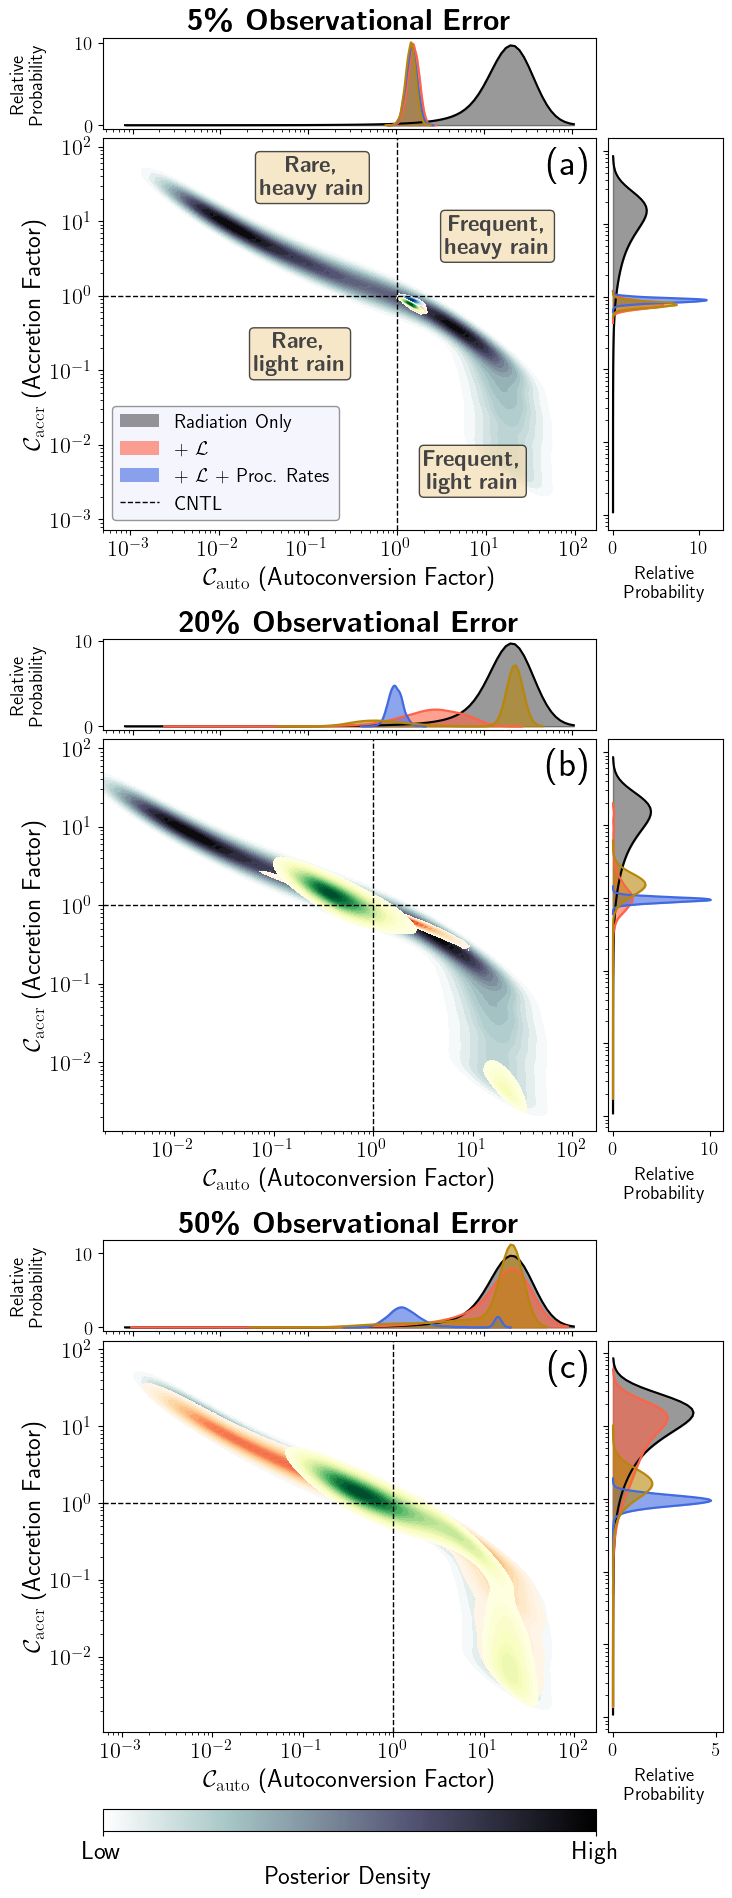

done


In [10]:
# ==============================================================================
# 0. DATA LOADING AND PREPARATION
# ==============================================================================
# This new section replaces the need to have pre-loaded dataframes.
post_GPerr_prop_bool = False
# Define the experiments and error levels we need
if post_GPerr_prop_bool:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withPostGPerrProp',
        'rad_lwp_prox': 'Radiation_Plus_LWP_ProxyRates_{}PercErr_VarCov_nothin_withPostGPerrProp'
    }

else:
    experiment_bases = {
        'rad': 'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp': 'Radiation_Plus_LWP_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_proc': 'Radiation_Plus_LWP_ProcessRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp',
        'rad_lwp_prox': 'Radiation_Plus_LWP_ProxyRates_{}PercErr_VarCov_nothin_withoutPostGPerrProp'
    }

error_percs = [5, 20, 50]
all_dataframes = {}
MAX_SAMPLES_FOR_PLOT = 5000
sub_samp_bool = True

print("--- Loading and preparing dataframes from .pkl files ---")
for name, template in experiment_bases.items():
    all_dataframes[name] = {}
    if '{}' in template: # It's an experiment with varying error
        for perc in error_percs:
            exp_name = template.format(perc)
            filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
            with open(filepath, "rb") as f:
                data_dict = pickle.load(f)
            
            # Create a DataFrame from the posterior input chains
            df = pd.DataFrame({
                'x_auto': data_dict['posteriors']['inputs']['x_auto'],
                'x_accr': data_dict['posteriors']['inputs']['x_accr']
            })
            if sub_samp_bool:
                df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42) # Subsample the data
            
            all_dataframes[name][perc] = df
            print(f"Loaded and created DataFrame for {name} @ {perc}%")
            
    else: # It's the baseline 'rad' experiment
        filepath = f'./mcmc_prop/constrained_prop_{template}.pkl'
        with open(filepath, "rb") as f:
            data_dict = pickle.load(f)
        
        df = pd.DataFrame({
            'x_auto': data_dict['posteriors']['inputs']['x_auto'],
            'x_accr': data_dict['posteriors']['inputs']['x_accr']
        })
        if sub_samp_bool:
            df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42) # Subsample the data
        
        all_dataframes[name] = df
        print(f"Loaded and created DataFrame for {name}")

# Assume df_cntl is loaded from elsewhere for the CNTL lines, or define it here
# For this example, let's create a dummy one since it's just for the (1,1) point
df_cntl = pd.DataFrame({'x_auto': [1.0], 'x_accr': [1.0]})


# ==============================================================================
# 1. HELPER FUNCTION TO DRAW ONE PANEL (Unchanged)
# ==============================================================================
def plot_panel(ax_joint, ax_marg_x, ax_marg_y, df_rad, df_lwp, df_lwp_proc, df_lwp_prox, plot_params):
    """Draws a complete joint+marginal KDE plot with CORRECTED marginals for log scale."""
    color1, color2, color3, color4 = plot_params['colors']
    cmap1, cmap2, cmap3, cmap4 = plot_params['cmaps']
    alpha1_2d, alpha2_2d, alpha3_2d, alpha4_2d = plot_params['alphas_2d']
    alpha1_1d, alpha2_1d, alpha3_1d, alpha4_1d = plot_params['alphas_1d']
    fill, linewidths = plot_params['fill'], plot_params['linewidths']
    gridsize, levels = plot_params['gridsize'], plot_params['levels']
    Fontsize = plot_params['Fontsize']

    sns.kdeplot(data=df_rad, x='x_auto', y='x_accr', cmap=cmap1, fill=fill, alpha=alpha1_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)
    sns.kdeplot(data=df_lwp, x='x_auto', y='x_accr', cmap=cmap2, fill=fill, alpha=alpha2_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)
    sns.kdeplot(data=df_lwp_proc, x='x_auto', y='x_accr', cmap=cmap3, fill=fill, alpha=alpha3_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)
    sns.kdeplot(data=df_lwp_prox, x='x_auto', y='x_accr', cmap=cmap4, fill=fill, alpha=alpha4_2d, ax=ax_joint, log_scale=True, gridsize=gridsize, levels=levels, linewidths=linewidths)

    def plot_corrected_kde(data, var, ax, orientation, color, alpha, **kwargs):
        kde_calc = sns.kdeplot(data=data, x=var if orientation == 'horizontal' else None, y=var if orientation == 'vertical' else None, ax=ax, log_scale=True, linewidth=0, **kwargs)
        line = ax.get_lines()[-1]
        x, y = line.get_data()
        line.remove()
        if orientation == 'horizontal':
            y_transformed = y * x
            ax.plot(x, y_transformed, color=color)
            ax.fill_between(x, 0, y_transformed, color=color, alpha=alpha)
        else:
            x_transformed = y * x
            ax.plot(x_transformed, y, color=color)
            ax.fill_betweenx(y, 0, x_transformed, color=color, alpha=alpha)

    plot_corrected_kde(df_rad, 'x_auto', ax_marg_x, 'horizontal', color1, alpha1_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp, 'x_auto', ax_marg_x, 'horizontal', color2, alpha2_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_proc, 'x_auto', ax_marg_x, 'horizontal', color3, alpha3_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_prox, 'x_auto', ax_marg_x, 'horizontal', color4, alpha4_1d, gridsize=gridsize)
    plot_corrected_kde(df_rad, 'x_accr', ax_marg_y, 'vertical', color1, alpha1_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp, 'x_accr', ax_marg_y, 'vertical', color2, alpha2_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_proc, 'x_accr', ax_marg_y, 'vertical', color3, alpha3_1d, gridsize=gridsize)
    plot_corrected_kde(df_lwp_prox, 'x_accr', ax_marg_y, 'vertical', color4, alpha4_1d, gridsize=gridsize)

# ==============================================================================
# 2. DEFINE PLOTTING PARAMETERS (Unchanged)
# ==============================================================================
Fontsize=18
plot_params = { 'gridsize': 100, 'levels': np.arange(0.05, 1.05, 0.05), 'colors': ('k', 'tomato', 'royalblue','darkgoldenrod'), 'cmaps': ('bone_r', 'OrRd', 'Blues','YlGn'), 'alphas_2d': (1., 1., 1., 1.), 'alphas_1d': (0.4, 0.6, 0.6, 0.6), 'fill': True, 'linewidths': 0, 'Fontsize': Fontsize }
cntl_x_auto = df_cntl['x_auto'].iloc[0]
cntl_x_accr = df_cntl['x_accr'].iloc[0]

# ==============================================================================
# 3. CREATE THE FIGURE LAYOUT AND AXES LISTS (More structured)
# ==============================================================================
fig = plt.figure(figsize=(8, 22))
gs = gridspec.GridSpec(17, 5, hspace=0.1, wspace=0.1)
panel_axes = [
    (fig.add_subplot(gs[1:5, 0:4]), fig.add_subplot(gs[0, 0:4]), fig.add_subplot(gs[1:5, 4])),
    (fig.add_subplot(gs[7:11, 0:4]), fig.add_subplot(gs[6, 0:4]), fig.add_subplot(gs[7:11, 4])),
    (fig.add_subplot(gs[13:17, 0:4]), fig.add_subplot(gs[12, 0:4]), fig.add_subplot(gs[13:17, 4]))
]
joint_axes = [axes[0] for axes in panel_axes]
marg_x_axes = [axes[1] for axes in panel_axes]
marg_y_axes = [axes[2] for axes in panel_axes]

# ==============================================================================
# 4. MAIN PLOTTING LOOP (Replaces repetitive calls)
# ==============================================================================
df_rad_base = all_dataframes['rad']
for i, perc in enumerate(error_percs):
    # Get the correct axes for this panel
    ax_joint, ax_marg_x, ax_marg_y = panel_axes[i]
    
    # Get the correct dataframes for this error percentage
    df_lwp_panel = all_dataframes['rad_lwp'][perc]
    df_lwp_proc_panel = all_dataframes['rad_lwp_proc'][perc]
    df_lwp_prox_panel = all_dataframes['rad_lwp_prox'][perc]
    
    # Call the panel plotting function
    plot_panel(ax_joint, ax_marg_x, ax_marg_y, df_rad_base, df_lwp_panel, df_lwp_proc_panel, df_lwp_prox_panel, plot_params)
    
# ==============================================================================
# 5. FINAL PLOT TOUCHES (Largely unchanged, but using axes lists)
# ==============================================================================
fac = 0.75
panel_titles = [r"\textbf{5\% Observational Error}", r"\textbf{20\% Observational Error}", r"\textbf{50\% Observational Error}"]
for i, ax in enumerate(marg_x_axes):
    ax.set_title(panel_titles[i], fontsize=Fontsize*1.2)
    ax.set_ylabel('Relative\nProbability', fontsize=Fontsize * fac)
    plt.setp(ax.get_xticklabels(), visible=False) # Simplified removal
    ax.tick_params(axis='y', which='major', labelsize=Fontsize * fac)

for ax in joint_axes:
    ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
    ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
    ax.tick_params(axis='both', which='major', labelsize=Fontsize - 2)
    ax.axhline(cntl_x_accr, ls='dashed', lw=1, zorder=10, c='k')
    ax.axvline(cntl_x_auto, ls='dashed', lw=1, zorder=10, c='k')

for ax in marg_y_axes:
    ax.set_xlabel('Relative\nProbability', fontsize=Fontsize * fac)
    plt.setp(ax.get_yticklabels(), visible=False)
    ax.tick_params(axis='x', which='major', labelsize=Fontsize * fac)

# Create legend on the first panel
legend_elements = [
    mpatches.Patch(facecolor=plot_params['colors'][0], alpha=plot_params['alphas_1d'][0], label='Radiation Only'),
    mpatches.Patch(facecolor=plot_params['colors'][1], alpha=plot_params['alphas_1d'][1], label=r'+ $\mathcal{L}$'),
    mpatches.Patch(facecolor=plot_params['colors'][2], alpha=plot_params['alphas_1d'][2], label=r'+ $\mathcal{L}$ + Proc. Rates'),
    plt.Line2D([0], [0], color='k', label='CNTL', lw=1,ls='dashed')
]



# ==============================================================================
# 6. QUADRANT ANNOTATION ON PANEL (a)
# ==============================================================================
ax_annotate = joint_axes[0]
quadrant_style = dict(
    fontsize=Fontsize * 0.9,
    color='#444444',
    ha='center',
    va='center',
    fontstyle='italic',
    fontweight='bold',
    transform=ax_annotate.transAxes,
    zorder=20,
    bbox=dict(boxstyle='round,pad=0.2', facecolor='wheat', alpha=0.7, edgecolor='k')
)

# Upper-left quadrant: low C_auto, high C_accr
#ax_annotate.text(0.4, 0.85, 'Rare,\nheavy rain', **quadrant_style)
ax_annotate.text(0.425, 0.9, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)

# Upper-right quadrant: high C_auto, high C_accr
ax_annotate.text(0.8, 0.75, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{heavy rain}}', **quadrant_style)

# Lower-left quadrant: low C_auto, low C_accr
ax_annotate.text(0.4, 0.45, r'\textit{\textbf{Rare,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)

# Lower-right quadrant: high C_auto, low C_accr
ax_annotate.text(0.75, 0.15, r'\textit{\textbf{Frequent,}}' + '\n' + r'\textit{\textbf{light rain}}', **quadrant_style)


# ==============================================================================
# 7. HORIZONTAL COLORBAR AT BOTTOM
# ==============================================================================
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get position of bottom joint axis for placement reference
pos = joint_axes[2].get_position()

# Add colorbar axis below the bottom panel
cax = fig.add_axes([pos.x0, pos.y0 - 0.045, pos.width * 1., 0.01])

norm = mcolors.Normalize(vmin=0, vmax=1)
cb = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap='bone_r'),
    cax=cax,
    orientation='horizontal'
)
cb.set_ticks([0, 1])
cb.set_ticklabels(['Low', 'High'], fontsize=Fontsize * 1.)
cb.set_label('Posterior Density', fontsize=Fontsize * 1., labelpad=2)


joint_axes[0].legend(handles=legend_elements, loc='lower left', fontsize=Fontsize - 4, framealpha=0.4, edgecolor='k',facecolor='lavender')

# Add Panel Labels (a, b, c)
for i, ax in enumerate(joint_axes):
    ax.text(0.99,0.98, f'({chr(97+i)})', fontsize=Fontsize*1.5, va='top', ha='right', transform=ax.transAxes)

fig.align_labels()

for ax in marg_x_axes:
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), visible=False)

for ax in marg_y_axes:
    ax.set_ylabel('')
    plt.setp(ax.get_yticklabels(), visible=False)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
file_name = f'fig_xauto_accr_joint_KDE_3panel.png'
#plt.savefig(save_path + file_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print('done')

In [37]:
# Check that marginal peak aligns with expected value from samples directly
df_check = all_dataframes['rad']

# The marginal peak of C_auto should be near the mode of the samples

log_auto = np.log10(df_check['x_auto'])
print('Mode of log10(C_auto) samples:', 
      log_auto.value_counts(bins=100).idxmax())

# Compare to what the marginal plot is showing visually
# If these roughly agree, the code is correct

Mode of log10(C_auto) samples: (1.221, 1.258]


# Plot joint KDEs color-filled with mean variables as a hexplot

In [ ]:

# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
perc_err = 20
post_GPerr_prop_bool = False
sub_samp_bool = True
MAX_SAMPLES_FOR_PLOT = 10000

# ... (Your data loading loop is unchanged) ...
if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp'
    ]
col_titles = [
    r'\textbf{Radiation Only}',
    r'\textbf{+ $\mathcal{L}$ }',
    r'\textbf{+ $\mathcal{L}$ + Proc. Rates }',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
    })
    
    # --- START: NEW SUBSAMPLING LOGIC ---
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    # --- END: NEW SUBSAMPLING LOGIC ---
    
    dataframes.append(df)
    
# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (Unchanged)
# ==============================================================================
cmap1 = 'managua'
cmap2 = 'managua'
plot_configs = [
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
]
nrows, ncols = len(plot_configs), len(dataframes) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 10.5), constrained_layout=True)
Fontsize = 14

# ==============================================================================
# 3. MAIN PLOTTING LOOP (MODIFIED FOR HEXBIN)
# ==============================================================================
for row_idx, config in enumerate(plot_configs):
    var = config['var']
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    
    for col_idx, df in enumerate(dataframes):
        ax = axes[row_idx, col_idx]
        
        # --- START: REPLACED SCATTER WITH HEXBIN ---
        hexbin_plot = ax.hexbin(
            x=df['x_auto'], 
            y=df['x_accr'], 
            C=df[var],          # The variable to calculate the mean of
            reduce_C_function=np.mean, # Explicitly tell it to compute the mean
            gridsize=40,        # Number of hexagons in the x-direction
            cmap=config['cmap'],
            xscale='log',       # Set the scale for the binning
            yscale='log',
            vmin=vmin,
            vmax=vmax,
            # mincnt=1          # Optional: only show hexagons with at least 1 point
        )
        # --- END: REPLACEMENT ---
        
        # --- Conditional Formatting (largely unchanged) ---
        if col_idx == 0:
            ax.text(-0.285, 0.5, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='center', rotation=90,bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
            ax.set_ylabel(r'$C_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
        else: ax.set_yticklabels([])
            
        if row_idx == 0: ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
        
        if row_idx == nrows - 1: ax.set_xlabel(r'$C_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
        else: ax.set_xticklabels([])

        # --- Overlay KDE contours (unchanged) ---
        sns.kdeplot(data=df, x='x_auto', y='x_accr', ax=ax, levels=[0.05, 0.5, 0.9], colors='k', linewidths=1., linestyles=['solid','dashed','dotted'], gridsize=100, log_scale=True)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.tick_params(labelsize=Fontsize)
        
    # --- CREATE COLORBAR FOR THE ROW ---
    cbar_ax = axes[row_idx, -1]
    # Use the hexbin_plot object for the colorbar
    cbar = fig.colorbar(hexbin_plot, ax=cbar_ax, pad=0.02, extend='both')
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # --- Colorbar Notch (unchanged) ---
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD', 'ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2, bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)

# ==============================================================================
# 4. FINAL FORMATTING (Unchanged)
# ==============================================================================
# ... (rest of your final formatting code is unchanged) ...
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
for i in range(nrows):
    axes[i,1].set_yticklabels([])
    axes[i,2].set_yticklabels([])
    axes[0,i].set_xticklabels([])
    axes[1,i].set_xticklabels([])
    axes[i,1].set_ylabel('')
    axes[i,2].set_ylabel('')
    axes[0,i].set_xlabel('')
    axes[1,i].set_xlabel('')
labs = ['(a)','(b)','(c)', '(d)','(e)','(f)', '(g)','(h)','(i)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
axes[0,0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_joint_KDEs_{str(int(perc_err))}perc_hexplot.png'
#plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

## Same as above but reordering rows

In [38]:

# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
perc_err = 20
post_GPerr_prop_bool = False
sub_samp_bool = False
MAX_SAMPLES_FOR_PLOT = 10000

# ... (Your data loading loop is unchanged) ...
if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp'
    ]
col_titles = [
    r'\textbf{Radiation Only}',
    r'\textbf{+ $\mathcal{L}$ }',
    r'\textbf{+ $\mathcal{L}$ + Proc. Rates }',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
    })
    
    # --- START: NEW SUBSAMPLING LOGIC ---
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    # --- END: NEW SUBSAMPLING LOGIC ---
    
    dataframes.append(df)
    
# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (Unchanged)
# ==============================================================================
cmap1 = 'managua'
cmap2 = 'managua'
plot_configs = [
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
]
nrows, ncols = len(plot_configs), len(dataframes) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 10.5), constrained_layout=True)
Fontsize = 14


# ==============================================================================
# 3. PRE-COMPUTE GLOBAL AXIS LIMITS
# ==============================================================================
all_x = pd.concat([df['x_auto'] for df in dataframes])
all_y = pd.concat([df['x_accr'] for df in dataframes])

# Compute limits with some padding in log space
global_xlim = (all_x.min() * 0.8, all_x.max() * 1.2)
global_ylim = (all_y.min() * 0.8, all_y.max() * 1.2)



# ==============================================================================
# 3. MAIN PLOTTING LOOP (MODIFIED FOR HEXBIN)
# ==============================================================================
for row_idx, config in enumerate(plot_configs):
    var = config['var']
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    
    for col_idx, df in enumerate(dataframes):
        ax = axes[row_idx, col_idx]
        
        # --- START: REPLACED SCATTER WITH HEXBIN ---
        hexbin_plot = ax.hexbin(
            x=df['x_auto'], 
            y=df['x_accr'], 
            C=df[var],          # The variable to calculate the mean of
            reduce_C_function=np.mean, # Explicitly tell it to compute the mean
            gridsize=40,        # Number of hexagons in the x-direction
            cmap=config['cmap'],
            xscale='log',       # Set the scale for the binning
            yscale='log',
            vmin=vmin,
            vmax=vmax,
            extent=[                          # <-- ADD THIS
                np.log10(global_xlim[0]),
                np.log10(global_xlim[1]),
                np.log10(global_ylim[0]),
                np.log10(global_ylim[1]),
            ],
            # mincnt=1          # Optional: only show hexagons with at least 1 point
        )
        # --- END: REPLACEMENT ---
        
        # --- Conditional Formatting (largely unchanged) ---
        if col_idx == 0:
            ax.text(-0.285, 0.5, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='center', rotation=90,bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
            ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
        else: ax.set_yticklabels([])
            
        if row_idx == 0: ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
        
        if row_idx == nrows - 1: ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
        else: ax.set_xticklabels([])

        # --- Overlay KDE contours (unchanged) ---
        sns.kdeplot(data=df, x='x_auto', y='x_accr', ax=ax, levels=[0.05, 0.5, 0.9], colors='k', linewidths=1., linestyles=['solid','dashed','dotted'], gridsize=100, log_scale=True)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.tick_params(labelsize=Fontsize)
        
    # --- CREATE COLORBAR FOR THE ROW ---
    cbar_ax = axes[row_idx, -1]
    # Use the hexbin_plot object for the colorbar
    cbar = fig.colorbar(hexbin_plot, ax=cbar_ax, pad=0.02, extend='both')
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # --- Colorbar Notch (unchanged) ---
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD', 'ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2, bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)

# ==============================================================================
# 4. FINAL FORMATTING (Unchanged)
# ==============================================================================
# ... (rest of your final formatting code is unchanged) ...
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
for i in range(nrows):
    axes[i,1].set_yticklabels([])
    axes[i,2].set_yticklabels([])
    axes[0,i].set_xticklabels([])
    axes[1,i].set_xticklabels([])
    axes[i,1].set_ylabel('')
    axes[i,2].set_ylabel('')
    axes[0,i].set_xlabel('')
    axes[1,i].set_xlabel('')
labs = ['(a)','(b)','(c)', '(d)','(e)','(f)', '(g)','(h)','(i)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
axes[0,0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_joint_KDEs_{str(int(perc_err))}perc_hexplot.png'
plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl
done


In [15]:

# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
perc_err = 20
post_GPerr_prop_bool = False
sub_samp_bool = False
MAX_SAMPLES_FOR_PLOT = 5000

# ... (Your data loading loop is unchanged) ...
if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
    ]
col_titles = [
    r'\textbf{Radiation Only}',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
    })
    
    # --- START: NEW SUBSAMPLING LOGIC ---
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    # --- END: NEW SUBSAMPLING LOGIC ---
    
    dataframes.append(df)
    
# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (Unchanged)
# ==============================================================================
cmap1 = 'managua'
cmap2 = 'managua'
plot_configs = [
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\mathcal{L_{\mathrm{PD}}}/\mathcal{L_{\mathrm{PI}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
    #{'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
]
nrows, ncols = len(plot_configs), len(dataframes) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6, 10.5), constrained_layout=True)
Fontsize = 14


# ==============================================================================
# 3. PRE-COMPUTE GLOBAL AXIS LIMITS
# ==============================================================================
all_x = pd.concat([df['x_auto'] for df in dataframes])
all_y = pd.concat([df['x_accr'] for df in dataframes])

# Compute limits with some padding in log space
global_xlim = (all_x.min() * 0.8, all_x.max() * 1.2)
global_ylim = (all_y.min() * 0.8, all_y.max() * 1.2)



# ==============================================================================
# 3. MAIN PLOTTING LOOP (MODIFIED FOR HEXBIN)
# ==============================================================================
for row_idx, config in enumerate(plot_configs):
    var = config['var']
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    
    #for col_idx, df in enumerate(dataframes):
    if True:
        
        ax = axes[row_idx]
        df = dataframes[0]
        
        # --- START: REPLACED SCATTER WITH HEXBIN ---
        hexbin_plot = ax.hexbin(
            x=df['x_auto'], 
            y=df['x_accr'], 
            C=df[var],          # The variable to calculate the mean of
            reduce_C_function=np.mean, # Explicitly tell it to compute the mean
            gridsize=40,        # Number of hexagons in the x-direction
            cmap=config['cmap'],
            xscale='log',       # Set the scale for the binning
            yscale='log',
            vmin=vmin,
            vmax=vmax,
            extent=[                          # <-- ADD THIS
                np.log10(global_xlim[0]),
                np.log10(global_xlim[1]),
                np.log10(global_ylim[0]),
                np.log10(global_ylim[1]),
            ],
            # mincnt=1          # Optional: only show hexagons with at least 1 point
        )
        # --- END: REPLACEMENT ---
        
        # --- Conditional Formatting (largely unchanged) ---
        #if col_idx == 0:
            #ax.text(-0.285, 0.5, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='center', rotation=90,bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
        ax.text(0.5,0.97, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='top', bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
        ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
        #else: ax.set_yticklabels([])
            
        #if row_idx == 0: ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
        
        if row_idx == nrows - 1: ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)
        else: ax.set_xticklabels([])

        # --- Overlay KDE contours (unchanged) ---
        sns.kdeplot(data=df, x='x_auto', y='x_accr', ax=ax, levels=[0.05, 0.5, 0.9], colors='k', linewidths=1., linestyles=['dotted','dashed','solid'], gridsize=100, log_scale=True)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.tick_params(labelsize=Fontsize)
        
    # --- CREATE COLORBAR FOR THE ROW ---
    cbar_ax = axes[row_idx]
    # Use the hexbin_plot object for the colorbar
    cbar = fig.colorbar(hexbin_plot, ax=cbar_ax, pad=0.02, extend='both')
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # --- Colorbar Notch (unchanged) ---
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD', 'ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2, bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)

# ==============================================================================
# 4. FINAL FORMATTING (Unchanged)
# ==============================================================================
# ... (rest of your final formatting code is unchanged) ...
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
for i in range(nrows-1):
    #axes[i,1].set_yticklabels([])
    #axes[i,2].set_yticklabels([])
    axes[i].set_xticklabels([])
    axes[i].set_xticklabels([])
    #axes[i,1].set_ylabel('')
    #axes[i,2].set_ylabel('')
    axes[i].set_xlabel('')
    axes[i].set_xlabel('')
labs = ['(a)','(b)','(c)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
lgnd1 = axes[0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)

dum_color='firebrick'
for ax in axes:
    ax.axhline(1,lw=1.5,ls='dashed',c=dum_color,label='CNTL')
    ax.axvline(1,lw=1.5,ls='dashed',c=dum_color)

custom_lines = [
    Line2D([0], [0], color=dum_color, lw=1.5, ls='dashed', label=r'CNTL'),
]
labels = [line.get_label() for line in custom_lines]
lgnd2 = axes[0].legend(custom_lines,labels,loc='lower left',frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,bbox_to_anchor=(0.005,0.25))

axes[0].add_artist(lgnd1)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_joint_KDEs_{str(int(perc_err))}perc_hexplot.png'
plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
done


--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 5000 points.


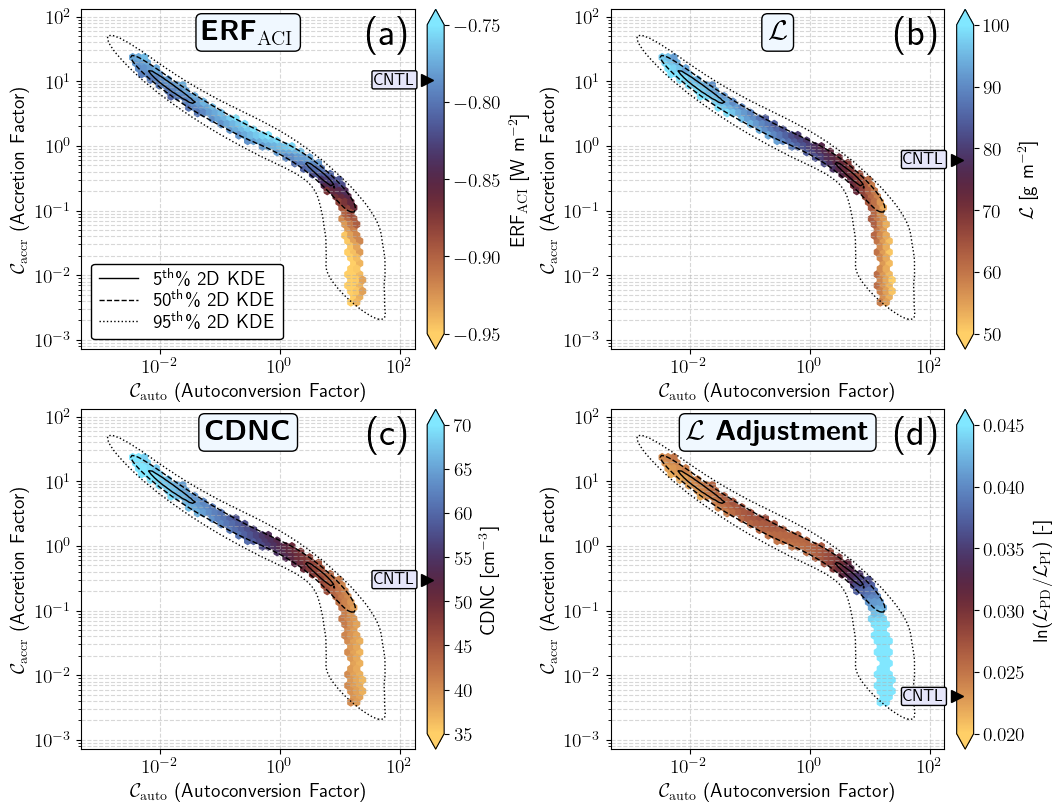

done


In [126]:

# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
perc_err = 20
post_GPerr_prop_bool = False
sub_samp_bool = True
MAX_SAMPLES_FOR_PLOT = 5000

# ... (Your data loading loop is unchanged) ...
if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
    ]
col_titles = [
    r'\textbf{Radiation Only}',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
        'CDNC_PD': plot_data['posteriors']['CDNC_PD'],
    })
    
    # --- START: NEW SUBSAMPLING LOGIC ---
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    # --- END: NEW SUBSAMPLING LOGIC ---
    
    dataframes.append(df)
    
# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (Unchanged)
# ==============================================================================
cmap1 = 'managua'
cmap2 = 'managua'
plot_configs = [
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'CDNC_PD', 'title': r'\textbf{CDNC}', 'cbar_label': r'CDNC [cm$^{-3}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['CDNC_PD'].iloc[0], 0)} cm$^{{-3}}$",'vmin':35,'vmax':70},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\mathcal{L_{\mathrm{PD}}}/\mathcal{L_{\mathrm{PI}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
    #{'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
]
nrows, ncols = 2, 2
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10.5, 8), constrained_layout=True)
Fontsize = 14


# ==============================================================================
# 3. PRE-COMPUTE GLOBAL AXIS LIMITS
# ==============================================================================
all_x = pd.concat([df['x_auto'] for df in dataframes])
all_y = pd.concat([df['x_accr'] for df in dataframes])

# Compute limits with some padding in log space
global_xlim = (all_x.min() * 0.8, all_x.max() * 1.2)
global_ylim = (all_y.min() * 0.8, all_y.max() * 1.2)


axes_flat = np.ndarray.flatten(axes)
# ==============================================================================
# 3. MAIN PLOTTING LOOP (MODIFIED FOR HEXBIN)
# ==============================================================================
for i,config in enumerate(plot_configs):
    var = config['var']
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    

    ax = axes_flat[i]
    df = dataframes[0]
        
    # --- START: REPLACED SCATTER WITH HEXBIN ---
    hexbin_plot = ax.hexbin(
        x=df['x_auto'], 
        y=df['x_accr'], 
        C=df[var],          # The variable to calculate the mean of
        reduce_C_function=np.mean, # Explicitly tell it to compute the mean
        gridsize=40,        # Number of hexagons in the x-direction
        cmap=config['cmap'],
        xscale='log',       # Set the scale for the binning
        yscale='log',
        vmin=vmin,
        vmax=vmax,
        extent=[                          # <-- ADD THIS
            np.log10(global_xlim[0]),
            np.log10(global_xlim[1]),
            np.log10(global_ylim[0]),
            np.log10(global_ylim[1]),
        ],
        # mincnt=1          # Optional: only show hexagons with at least 1 point
    )
    # --- END: REPLACEMENT ---
    
    # --- Conditional Formatting (largely unchanged) ---
    ax.text(0.5,0.97, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='top', bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
    ax.set_ylabel(r'$\mathcal{C}_{\mathrm{accr}}$ (Accretion Factor)', fontsize=Fontsize)
        
    #if row_idx == 0: ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
    
    ax.set_xlabel(r'$\mathcal{C}_{\mathrm{auto}}$ (Autoconversion Factor)', fontsize=Fontsize)

    # --- Overlay KDE contours (unchanged) ---
    sns.kdeplot(data=df, x='x_auto', y='x_accr', ax=ax, levels=[0.05, 0.5, 0.9], colors='k', linewidths=1., linestyles=['dotted','dashed','solid'], gridsize=100, log_scale=True)
    
    ax.grid(True, which="both", ls="--", alpha=0.5)
    ax.tick_params(labelsize=Fontsize)
        
    # --- CREATE COLORBAR FOR THE ROW ---
    cbar_ax = axes_flat[i]
    # Use the hexbin_plot object for the colorbar
    cbar = fig.colorbar(hexbin_plot, ax=cbar_ax, pad=0.02, extend='both')
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # --- Colorbar Notch (unchanged) ---
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD','CDNC_PD','ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2, bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)


# ==============================================================================
# 4. FINAL FORMATTING (Unchanged)
# ==============================================================================
# ... (rest of your final formatting code is unchanged) ...
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

labs = ['(a)','(b)','(c)','(d)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
axes_flat[0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)

save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_joint_KDEs_{str(int(perc_err))}perc_hexplot.png'
#plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

In [34]:
# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
perc_err = 20

experiment_names = [
    'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
    f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp',
    f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp'
]

dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
    })
    
    dataframes.append(df)


--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl


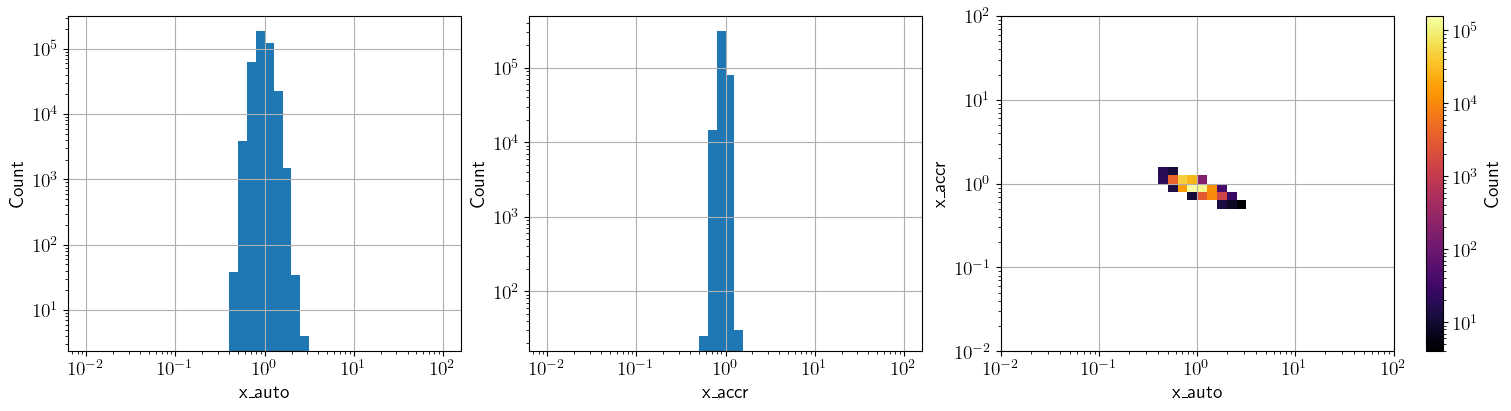

In [35]:
fig = plt.figure(figsize=(15,4),constrained_layout=True)
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
axlist = [ax1,ax2,ax3]
Fontsize=14
for ax in axlist:
    ax.tick_params(labelsize=Fontsize)
    ax.grid()
    ax.set_xscale('log')
    ax.set_yscale('log')

ax1.set_ylabel('Count',fontsize=Fontsize)
ax2.set_ylabel('Count',fontsize=Fontsize)

ax1.set_xlabel('x_auto',fontsize=Fontsize)
ax2.set_xlabel('x_accr',fontsize=Fontsize)
ax2.set_xlabel('x_accr',fontsize=Fontsize)

ax1.hist(dataframes[2]['x_auto'].values,bins=10.**np.arange(-2,2.1,0.1))
ax2.hist(dataframes[2]['x_accr'].values,bins=10.**np.arange(-2,2.1,0.1))

ax3.set_xlabel('x_auto',fontsize=Fontsize)
ax3.set_ylabel('x_accr',fontsize=Fontsize)
tmpplot=ax3.hist2d(dataframes[2]['x_auto'].values,dataframes[2]['x_accr'].values,cmap='inferno',bins=10.**np.arange(-2,2.1,0.1),norm=mpl.colors.LogNorm())
cbar = plt.colorbar(tmpplot[3])
cbar.ax.tick_params(labelsize=Fontsize)
cbar.ax.set_ylabel('Count',fontsize=Fontsize)

plt.show()
plt.close()

# Plot joint KDEs color-filled with variablse as a scatterplot

--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 50000 points.
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 50000 points.
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov_nothin_withPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 50000 points.


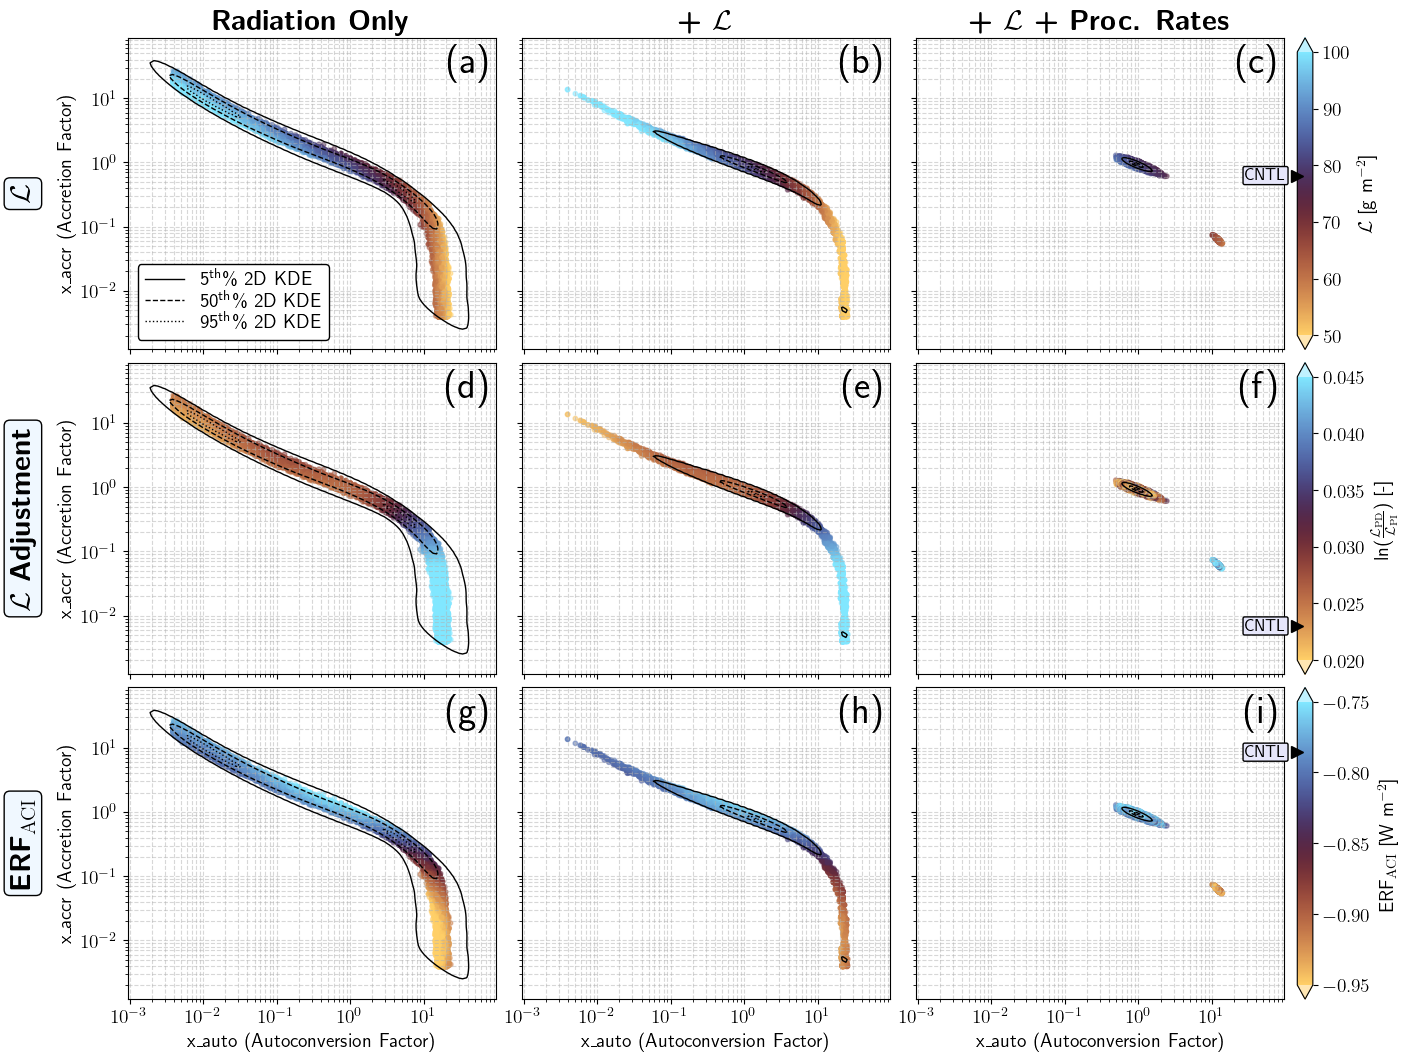

done


In [11]:
# ==============================================================================
# 0. MAIN CONFIGURATION
# ==============================================================================
perc_err = 20
post_GPerr_prop_bool = False

# --- NEW: Subsampling Configuration ---
sub_samp_bool = True # <<< SET THIS TO True TO ENABLE SUBSAMPLING
MAX_SAMPLES_FOR_PLOT = 10000 # Number of points to use for plotting if subsampling

# ==============================================================================
# 1. DATA LOADING AND PREPARATION
# ==============================================================================
if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]

col_titles = [
    r'\textbf{Radiation Only}',
    r'\textbf{+ $\mathcal{L}$ }',
    r'\textbf{+ $\mathcal{L}$ + Proc. Rates }',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
    })
    
    # --- START: NEW SUBSAMPLING LOGIC ---
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    # --- END: NEW SUBSAMPLING LOGIC ---
    
    dataframes.append(df)

# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (The rest of the script is unchanged)
# ==============================================================================
# Assume df_cntl and df_cntl_regime2 are loaded elsewhere
# ... (rest of your plotting code)
cmap1 = 'managua'
cmap2 = 'managua'
cmap3 = 'managua'
#cmap3 = 'berlin'
# --- 2. DEFINE PLOT CONFIGURATIONS ---
plot_configs = [
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
]
bbox_props = dict(boxstyle="round,pad=0.2", facecolor="lavender", edgecolor="black", alpha=0.8, linewidth=1.0)
# --- 3. SETUP FIGURE AND PLOT IN A SINGLE NESTED LOOP ---
# CORRECTED: The number of rows is determined by plot_configs, and columns by dataframes.
nrows, ncols = len(plot_configs), len(dataframes) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 10.5), constrained_layout=True)
Fontsize = 14
# --- The Main Consolidated Loop ---
for row_idx, config in enumerate(plot_configs):
    var = config['var']
    
    # Determine shared color limits for the entire row (once per row for efficiency)
    all_vals_for_var = pd.concat([d[var] for d in dataframes])
    #vmin, vmax = all_vals_for_var.min(), all_vals_for_var.max()
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    
    # --- Inner loop to plot each panel in the row ---
    for col_idx, df in enumerate(dataframes):
        ax = axes[row_idx, col_idx]
        
        # --- Plotting Logic (Scatter) ---
        # The 'scatter_plot' object will be updated each time, 
        # but we only need the last one for the colorbar.
        scatter_plot = ax.scatter(
            df['x_auto'], df['x_accr'], c=df[var],
            cmap=config['cmap'], alpha=0.5, s=10, vmin=vmin, vmax=vmax
        )
        
        # --- Per-panel Annotation ---
        #ax.text(0.02, 0.02, config['cntl_val_str'], transform=ax.transAxes, fontsize=Fontsize*1.25, 
        #        ha='left', va='bottom', bbox=bbox_props)
        
        # --- Conditional Formatting for Titles and Labels ---
        if col_idx == 0:
            # Add y-axis title and row title to the first column
            ax.text(-0.285, 0.5, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, 
                    ha='center', va='center', rotation=90,bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
            ax.set_ylabel(r'x_accr (Accretion Factor)', fontsize=Fontsize)
        else:
            # Remove y-tick labels for inner plots
            ax.set_yticklabels([])
        if row_idx == 0:
            # Add column titles to the top row
            ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
            
        if row_idx == nrows - 1:
            # Add x-axis label to the bottom row
            ax.set_xlabel(r'x_auto (Autoconversion Factor)', fontsize=Fontsize)
        else:
            # Remove x-tick labels for inner plots
            ax.set_xticklabels([])
        # Overlay the density contours
        # This calculates a 2D KDE and draws lines at specific density levels.
        if True:
            sns.kdeplot(
                data=df, x='x_auto', y='x_accr',
                ax=ax,
                levels=[0.05, 0.5, 0.9], # Draw contours for 5%, 25%, 50%, 95% of the density
                colors='k',
                linewidths=1.,
                #linestyles='solid',
                linestyles=['solid','dashed','dotted'],
                gridsize=100,
                log_scale=True # Important: tell kdeplot the axes are log-scaled
            )
        
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.tick_params(labelsize=Fontsize)
    # --- CREATE COLORBAR FOR THE ROW (AFTER INNER LOOP) ---
    # Attach the colorbar to the rightmost axis of the current row
    cbar_ax = axes[row_idx, -1] # Use -1 to always get the last column
    cbar = fig.colorbar(scatter_plot, ax=cbar_ax, pad=0.02,extend='both') # 'pad' adds a small space
    cbar.solids.set_alpha(1) # Make colorbar opaque
    
    # --- Formatting and Annotation for the Colorbar ---
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # Add the left-sided colorbar notch
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD', 'ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2,
                       bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)
    # ----------------------------------------------------
# --- 4. FINAL FORMATTING ---
# It's better to calculate these once and apply them, as you were doing.
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
for i in range(nrows):
    axes[i,1].set_yticklabels([])
    axes[i,2].set_yticklabels([])
    axes[0,i].set_xticklabels([])
    axes[1,i].set_xticklabels([])
    axes[i,1].set_ylabel('')
    axes[i,2].set_ylabel('')
    axes[0,i].set_xlabel('')
    axes[1,i].set_xlabel('')
labs = ['(a)','(b)','(c)',\
        '(d)','(e)','(f)',\
        '(g)','(h)','(i)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    #Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5, 50, 95 \% 2D KDEs'),
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
axes[0,0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)
save_path = '/glade/u/home/mckenna/work/figures/pnas_paper/'
fig_name = fr'fig_joint_KDEs_{str(int(perc_err))}perc.png'
#plt.savefig(save_path+fig_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

# Plot joint KDEs color-filled with mean variables as a pixelated joint histogram

--- Loading data and creating dataframes ---
Loading: ./mcmc_prop/constrained_prop_Radiation_Only_VarCov_nothin_withoutPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 10000 points.
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_20PercErr_VarCov_nothin_withoutPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 10000 points.
Loading: ./mcmc_prop/constrained_prop_Radiation_Plus_LWP_ProcessRates_20PercErr_VarCov_nothin_withPostGPerrProp.pkl
  -> Subsampling dataframe from 400000 to 10000 points.


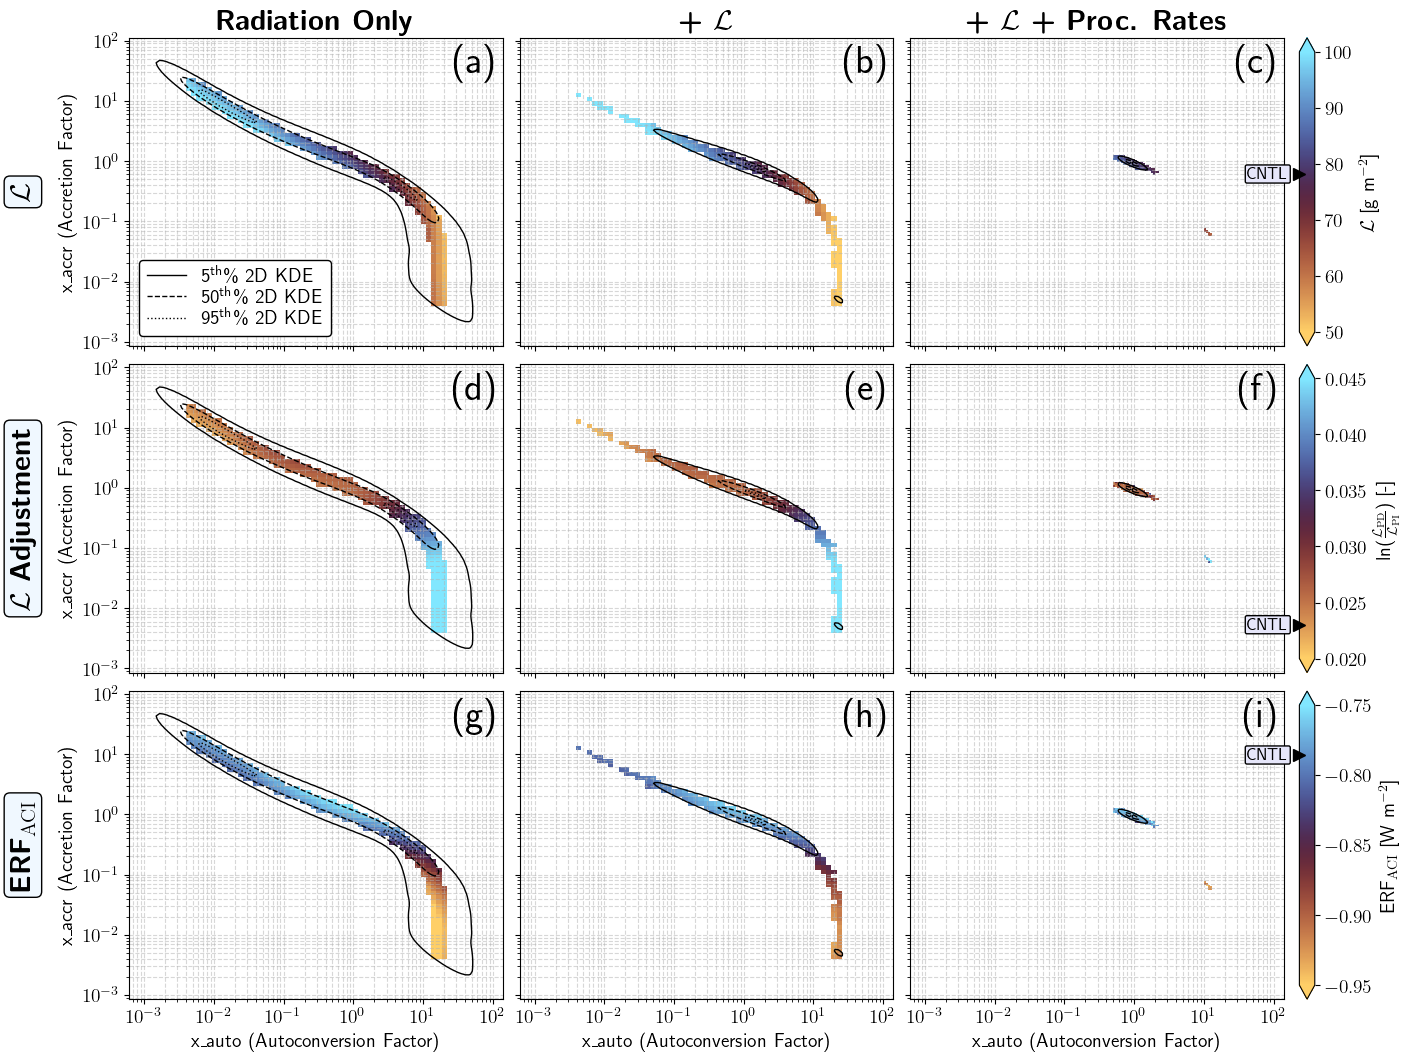

done


In [14]:
from scipy.stats import binned_statistic_2d # <<< Import the key function

# ==============================================================================
# 0. MAIN CONFIGURATION & 1. DATA LOADING (Unchanged)
# ==============================================================================
# ... (Your data loading code is unchanged) ...
perc_err = 20
post_GPerr_prop_bool = False
sub_samp_bool = True
MAX_SAMPLES_FOR_PLOT = 10000

if post_GPerr_prop_bool:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]
else:
    experiment_names = [
        'Radiation_Only_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_{perc_err}PercErr_VarCov_nothin_withoutPostGPerrProp',
        f'Radiation_Plus_LWP_ProcessRates_{perc_err}PercErr_VarCov_nothin_withPostGPerrProp'
    ]
col_titles = [
    r'\textbf{Radiation Only}',
    r'\textbf{+ $\mathcal{L}$ }',
    r'\textbf{+ $\mathcal{L}$ + Proc. Rates }',
]
dataframes = []
print("--- Loading data and creating dataframes ---")
for exp_name in experiment_names:
    filepath = f'./mcmc_prop/constrained_prop_{exp_name}.pkl'
    print(f"Loading: {filepath}")
    with open(filepath, "rb") as file:
        plot_data = pickle.load(file)
        
    df = pd.DataFrame({
        **plot_data['posteriors']['inputs'],
        'LWP_PD': plot_data['posteriors']['LWP_PD'],
        'LWP_adj': plot_data['posteriors']['LWP_adj'],
        'ERF_ACI': plot_data['posteriors']['ERF_ACI'],
    })
    
    if sub_samp_bool and len(df) > MAX_SAMPLES_FOR_PLOT:
        print(f"  -> Subsampling dataframe from {len(df)} to {MAX_SAMPLES_FOR_PLOT} points.")
        df = df.sample(n=MAX_SAMPLES_FOR_PLOT, random_state=42)
    
    dataframes.append(df)
    
# ==============================================================================
# 2. DEFINE PLOT CONFIGURATIONS (Unchanged)
# ==============================================================================
cmap1 = 'managua'
cmap2 = 'managua'
plot_configs = [
    {'var': 'LWP_PD', 'title': r'\textbf{$\mathcal{L}$}', 'cbar_label': r'$\mathcal{L}$ [g m$^{-2}$]', 'cmap': cmap2, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['LWP_PD'].iloc[0], 2)} g m$^{{-2}}$",'vmin':50,'vmax':100},
    {'var': 'LWP_adj', 'title': r'\textbf{$\mathcal{L}$ Adjustment}', 'cbar_label': r'ln($\frac{\mathcal{L_{\mathrm{PD}}}}{\mathcal{L_{\mathrm{PI}}}}$) [-]', 'cmap': cmap2, 'cntl_val_str': f"",'vmin':0.02,'vmax':0.045},
    {'var': 'ERF_ACI', 'title': r'\textbf{ERF$_{\mathrm{ACI}}$}', 'cbar_label': r'ERF$_{\mathrm{ACI}}$ [W m$^{-2}$]', 'cmap': cmap1, 'cntl_val_str': f"CNTL = {np.around(df_cntl_regime2['ERF_ACI'].iloc[0], 2)} W m$^{{-2}}$",'vmin':-0.95,'vmax':-0.75},
]
nrows, ncols = len(plot_configs), len(dataframes) 
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 10.5), constrained_layout=True)
Fontsize = 14

# ==============================================================================
# 3. MAIN PLOTTING LOOP (MODIFIED FOR 2D HISTOGRAM)
# ==============================================================================
for row_idx, config in enumerate(plot_configs):
    var = config['var']
    vmin = config.get('vmin')
    vmax = config.get('vmax')
    
    for col_idx, df in enumerate(dataframes):
        ax = axes[row_idx, col_idx]
        
        # --- START: REPLACEMENT WITH 2D BINNED STATISTIC ---
        
        # Define the bins for the histogram. Since the axes are log-scaled, the bins must be in log-space.
        x_bins = np.logspace(np.log10(df['x_auto'].min()), np.log10(df['x_auto'].max()), 51) # 50 bins
        y_bins = np.logspace(np.log10(df['x_accr'].min()), np.log10(df['x_accr'].max()), 51) # 50 bins

        # Calculate the mean of the variable `var` in each 2D bin
        statistic, x_edge, y_edge, _ = binned_statistic_2d(
            x=df['x_auto'],
            y=df['x_accr'],
            values=df[var],
            statistic='mean',
            bins=[x_bins, y_bins]
        )
        
        # Use pcolormesh to plot the result. We need to transpose the statistic matrix.
        # pcolormesh needs the bin edges (x_edge, y_edge) and the values (statistic).
        mesh = ax.pcolormesh(
            x_edge, y_edge, statistic.T, 
            cmap=config['cmap'], 
            vmin=vmin, 
            vmax=vmax
        )

        # Set the axis scales AFTER plotting
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # --- END: REPLACEMENT ---
        
        # --- Conditional Formatting (unchanged) ---
        if col_idx == 0:
            ax.text(-0.285, 0.5, config['title'], transform=ax.transAxes, fontsize=Fontsize*1.5, ha='center', va='center', rotation=90,bbox=dict(boxstyle="round,pad=0.2", facecolor="aliceblue", edgecolor="black", alpha=1., linewidth=1.))
            ax.set_ylabel(r'x_accr (Accretion Factor)', fontsize=Fontsize)
        else: ax.set_yticklabels([])
            
        if row_idx == 0: ax.set_title(col_titles[col_idx], fontsize=Fontsize*1.5)
        
        if row_idx == nrows - 1: ax.set_xlabel(r'x_auto (Autoconversion Factor)', fontsize=Fontsize)
        else: ax.set_xticklabels([])

        # --- Overlay KDE contours (unchanged) ---
        sns.kdeplot(data=df, x='x_auto', y='x_accr', ax=ax, levels=[0.05, 0.5, 0.9], colors='k', linewidths=1., linestyles=['solid','dashed','dotted'], gridsize=100, log_scale=True)
        
        ax.grid(True, which="both", ls="--", alpha=0.5)
        ax.tick_params(labelsize=Fontsize)
        
    # --- CREATE COLORBAR FOR THE ROW ---
    cbar_ax = axes[row_idx, -1]
    # Use the `mesh` object from pcolormesh for the colorbar
    cbar = fig.colorbar(mesh, ax=cbar_ax, pad=0.02, extend='both')
    cbar.ax.set_ylabel(config['cbar_label'], fontsize=Fontsize)
    cbar.ax.tick_params(labelsize=Fontsize)
    
    # --- Colorbar Notch (unchanged) ---
    cntl_val = df_cntl[var].iloc[0] if var not in ['LWP_PD', 'ERF_ACI','LWP_adj'] else df_cntl_regime2[var].iloc[0]
    cbar.ax.plot(0.0, cntl_val, '>', color='black', markersize=8, transform=cbar.ax.get_yaxis_transform(), clip_on=False)
    txt = cbar.ax.text(-0.7, cntl_val, 'CNTL', ha='right', va='center', transform=cbar.ax.get_yaxis_transform(), fontsize=Fontsize-2, bbox=dict(boxstyle="round,pad=0.1", facecolor="lavender", edgecolor="black", alpha=1., linewidth=1.))
    txt.set_in_layout(False)
    
# ==============================================================================
# 4. FINAL FORMATTING (Unchanged)
# ==============================================================================
# ... (rest of your final formatting code is unchanged) ...
xlim = (min(ax.get_xlim()[0] for ax in axes.flat), max(ax.get_xlim()[1] for ax in axes.flat))
ylim = (min(ax.get_ylim()[0] for ax in axes.flat), max(ax.get_ylim()[1] for ax in axes.flat))
for ax in axes.flat:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
for i in range(nrows):
    axes[i,1].set_yticklabels([])
    axes[i,2].set_yticklabels([])
    axes[0,i].set_xticklabels([])
    axes[1,i].set_xticklabels([])
    axes[i,1].set_ylabel('')
    axes[i,2].set_ylabel('')
    axes[0,i].set_xlabel('')
    axes[1,i].set_xlabel('')
labs = ['(a)','(b)','(c)', '(d)','(e)','(f)', '(g)','(h)','(i)']
for i,ax in enumerate(np.ndarray.flatten(axes)):
    ax.text(0.99,0.98,labs[i],fontsize=Fontsize*2.,ha='right',va='top',transform=ax.transAxes)

custom_lines = [
    Line2D([0], [0], color='k', lw=1, ls='solid', label=r'5\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dashed', label=r'50\textsuperscript{th}\% 2D KDE'),
    Line2D([0], [0], color='k', lw=1, ls='dotted', label=r'95\textsuperscript{th}\% 2D KDE'),
]
labels = [line.get_label() for line in custom_lines]
axes[0,0].legend(custom_lines, labels, loc='lower left', frameon=True,fontsize=Fontsize,edgecolor='k',framealpha=1,labelspacing=0.2)
plt.show()
plt.close()
print('done')